# Importing Libraries

In [1]:
import re
import os
import ast
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from glob import glob
from matplotlib.lines import Line2D
from collections import defaultdict

# Loading data

In [2]:
data_path = "/Users/op24226/Desktop/Passiv/Data/PST_Data_20260216"

# Event files
event_files = sorted(glob(os.path.join(data_path, "*_Events_*_*.csv")))
print(f"Event files found: {len(event_files)}")

def get_house_id(filepath: str) -> str:
    return os.path.basename(filepath).split("_")[0]

# 3) Load into a dict: {house_id: dataframe}
events_by_house = defaultdict(list)

for f in event_files:
    hid = get_house_id(f)
    df = pd.read_csv(f)
    df["house_id"] = hid
    events_by_house[hid].append(df)

print(f"Houses loaded: {len(events_by_house)}")

events_by_house = {hid: pd.concat(dfs, ignore_index=True) for hid, dfs in events_by_house.items()}

Event files found: 9
Houses loaded: 9


In [3]:
house_id = "29962"   
df_house = events_by_house[house_id]


# Preprocessing Data

In [4]:
def fix_and_parse_nested_dict(x):
    if pd.isna(x) or str(x).strip() == '':
        return {}
    
    s = str(x).strip()
    
    # Fix 'key': 'value, (missing closing quote before comma)
    s = re.sub(r":\s*'([^']*),", r": '\1',", s)
    
    # Fix 'value: 'text' (missing opening quote before colon)
    s = re.sub(r"'(\w+):\s*'", r"'\1': '", s)
    
    #Ensure all keys have quotes and colons are properly formatted
    s = re.sub(r"'(\w+):\s+", r"'\1': ", s)
    
    try:
        return ast.literal_eval(s)
    except Exception as e:
    
        try:
            # Add missing quotes around values that look like words
            s = re.sub(r":\s*([a-zA-Z]\w*)([,\s\}])", r": '\1'\2", s)
            return ast.literal_eval(s)
        except:
            print(f"Failed to parse after fixes.")
            print(f"Error: {e}")
            print(f"String preview: {s[:200]}...\n")
            return {}

df_house['parsed_dict'] = df_house['Payload'].apply(fix_and_parse_nested_dict)

In [5]:
def explore_structure(data, indent=0):
    """
    Print the structure of your nested data
    """
    prefix = "  " * indent
    
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, (dict, list)):
                print(f"{prefix}{key}: ({type(value).__name__})")
                explore_structure(value, indent + 1)
            else:
                print(f"{prefix}{key}: {type(value).__name__} = {str(value)[:50]}")
    elif isinstance(data, list):
        print(f"{prefix}List with {len(data)} items")
        if data:
            print(f"{prefix}First item:")
            explore_structure(data[0], indent + 1)

print("Structure of sample row:")
explore_structure(df_house['parsed_dict'].iloc[10])

Structure of sample row:
type: str = hot_water
mode: str = advanced
layers: (list)
  List with 3 items
  First item:
    week: (dict)
      events: (list)
        List with 35 items
        First item:
          day: str = mon
          time: str = 00:00
          usage: str = none


In [6]:
print("Structure of first row:")
explore_structure(df_house['parsed_dict'].iloc[0])

Structure of first row:
uri: str = /v/1/heating/zones/1/schedules/basic
type: str = heating
zone: int = 1
mode: str = basic
layers: (list)
  List with 2 items
  First item:
    week: (dict)
      events: (list)
        List with 49 items
        First item:
          day: str = mon
          time: str = 00:00
          C: int = 17


In [7]:
explore_structure(df_house['parsed_dict'].iloc[1])

uri: str = /v/1/heating/zones/1/schedules/basic
type: str = heating
zone: int = 1
mode: str = basic
layers: (list)
  List with 2 items
  First item:
    week: (dict)
      events: (list)
        List with 49 items
        First item:
          day: str = mon
          time: str = 00:00
          C: int = 17


In [8]:
def flatten_with_original_data(parsed_dict, original_row, row_index):
    """
    Include original row data in each flattened row
    """
    rows = []
    
    # Get all other columns from original row (except parsed_dict)
    original_data = {k: v for k, v in original_row.items() 
                     if k != 'parsed_dict'}
    
    # Grab ALL scalar top-level fields (type, mode, zone, etc.)
    top_level_scalars = {
        k: v for k, v in parsed_dict.items()
        if k != 'layers' and not isinstance(v, (dict, list))
    }
    
    for layer_idx, layer in enumerate(parsed_dict.get('layers', [])):
        layer_type = list(layer.keys())[0] if layer else 'unknown'
        layer_data = layer.get(layer_type, {})
        
        layer_metadata = {k: v for k, v in layer_data.items() 
                         if k != 'events' and not isinstance(v, list)}
        
        events = layer_data.get('events', [])
        
        for event_idx, event in enumerate(events):
            row = {
                'original_index': row_index,
                **original_data,
                **top_level_scalars,          # type, mode, zone, anything else
                'layer_index': layer_idx,
                'layer_type': layer_type,
                'event_index': event_idx,
                **{f'{layer_type}_{k}': v for k, v in layer_metadata.items()},
                **event
            }
            rows.append(row)
    
    return rows

# Apply with original row data
all_rows = []
for idx, row in df_house.iterrows():
    flattened = flatten_with_original_data(row['parsed_dict'], row, idx)
    all_rows.extend(flattened)

df_flattened_with_original = pd.DataFrame(all_rows)
#df_flattened_with_original.head()

In [9]:
new_data = df_flattened_with_original

In [10]:
new_data = new_data.drop(new_data[new_data['type']== 'hot_water'].index)

new_data = new_data.drop(['Payload', 'uri', 'layer_index', 'layer_type', 'event_index'], axis=1)

In [11]:
# Keep only days where the weekly schedule is overriden
new_data["Timestamp"] = pd.to_datetime(new_data["Timestamp"], errors="coerce")
new_data['Timestamp'] = new_data['Timestamp'].dt.tz_localize("UTC")

new_data["datetime"] = pd.to_datetime(new_data["datetime"], utc = True, errors = "coerce")

# Set datetime to Timestamp where row is Nan
new_data["datetime"] = new_data["datetime"].fillna(new_data["Timestamp"])

new_data["day"] = new_data["day"].str.strip().str.lower()

# Fill override rows with weekday value for day column
#new_data["day"] = new_data["day"].fillna(new_data["datetime"].dt.day_name().str[:3].str.lower())

new_data["dow"] = new_data["Timestamp"].dt.day_name().str[:3].str.lower()

new_data["day"] = new_data["day"].fillna(new_data["dow"])

new_data = new_data[new_data["day"] == new_data["dow"]].copy()

# Plotting Overrides

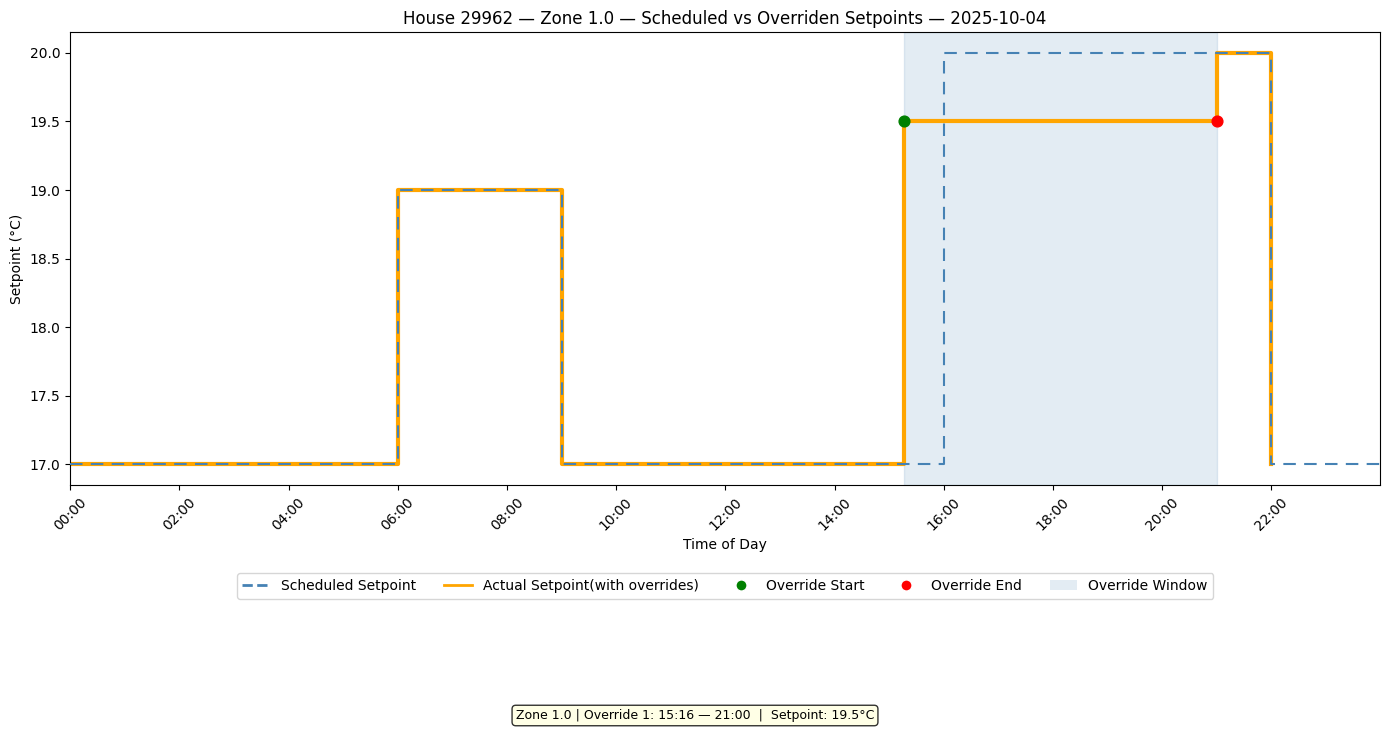

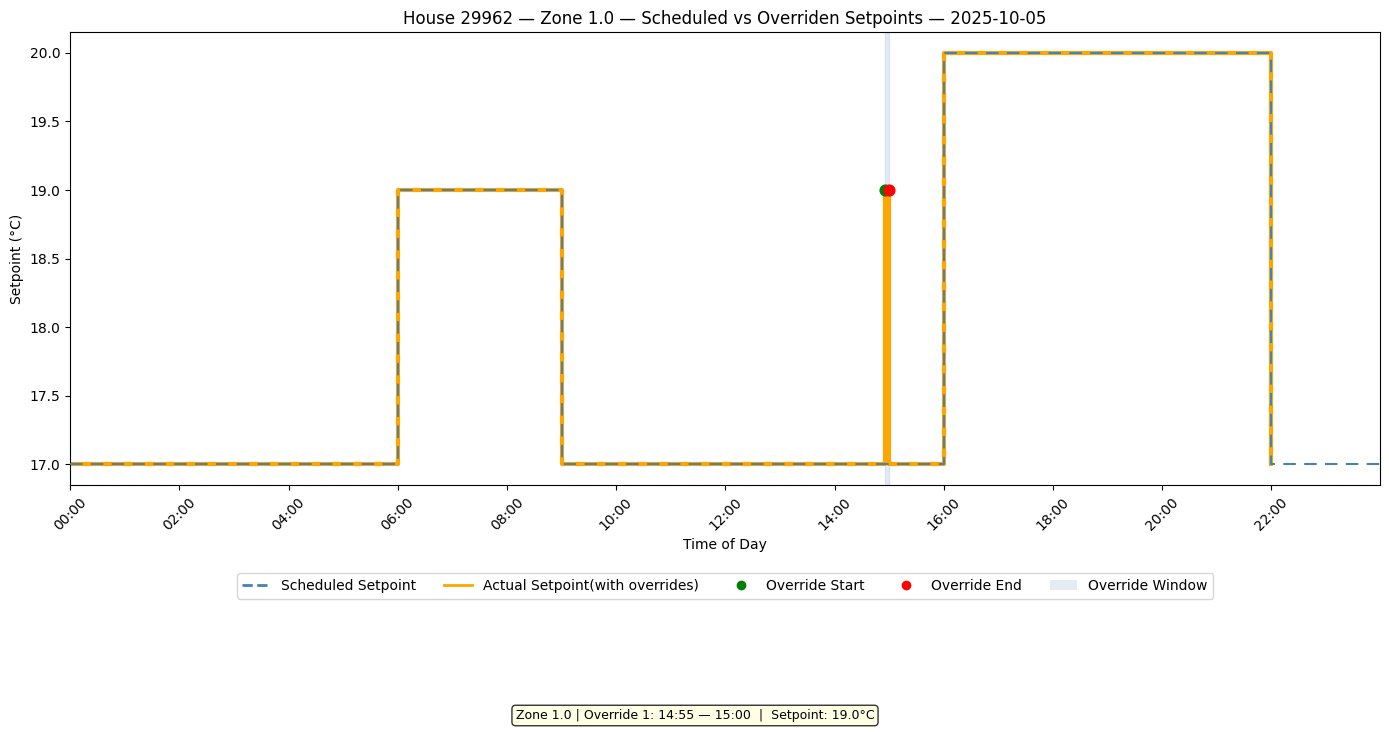

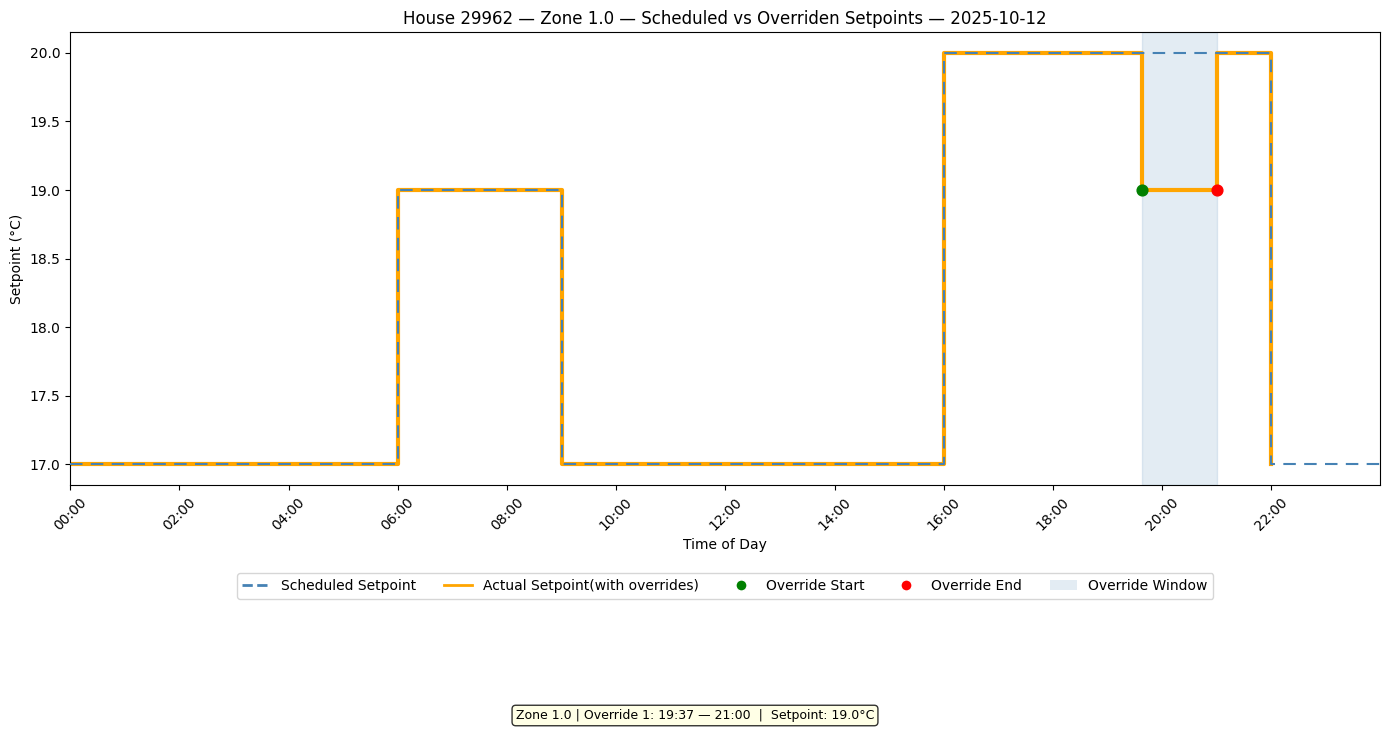

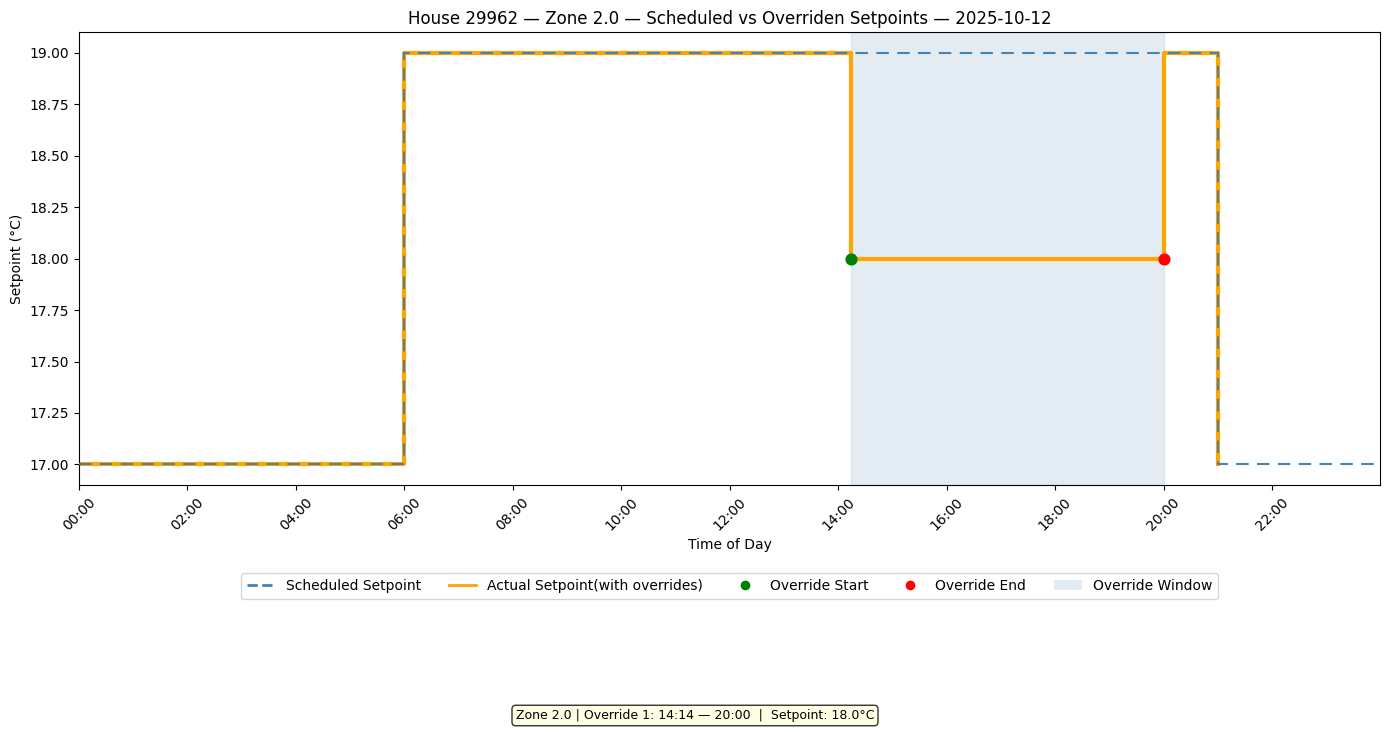

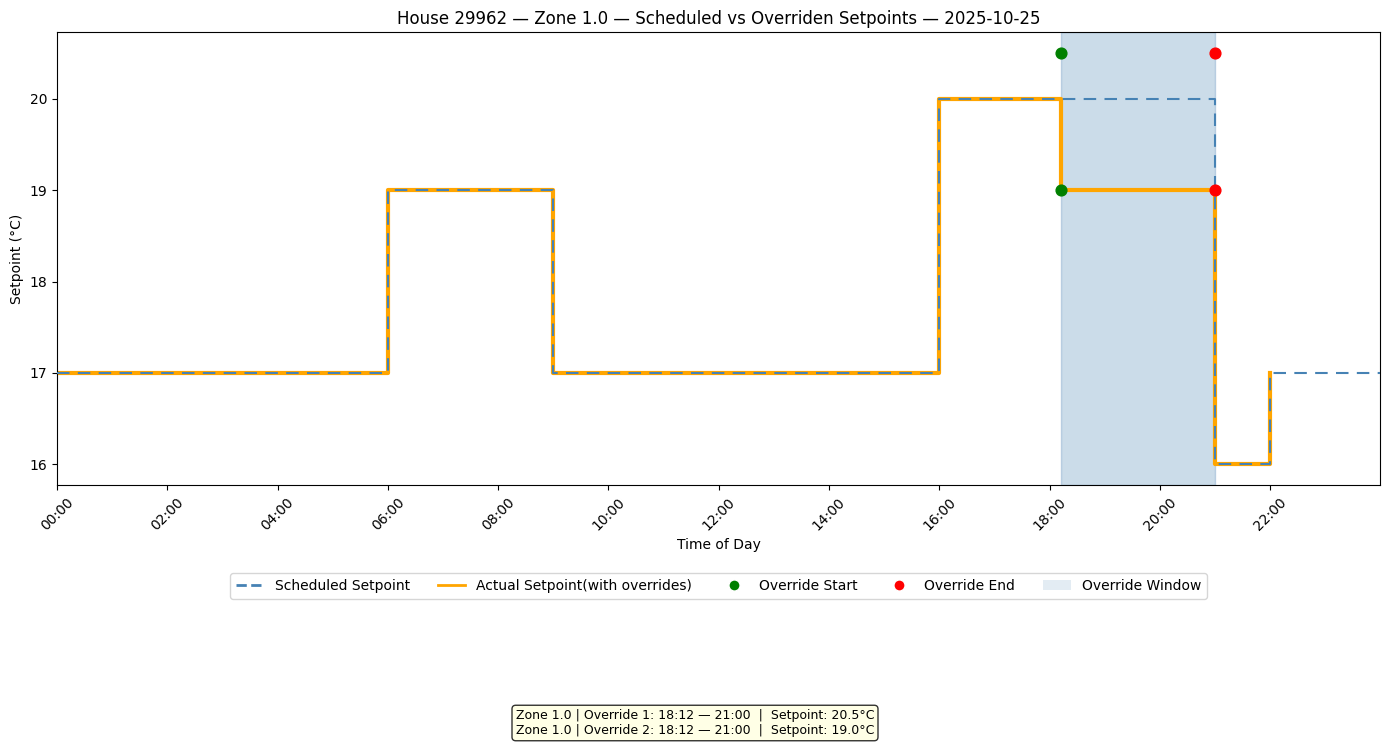

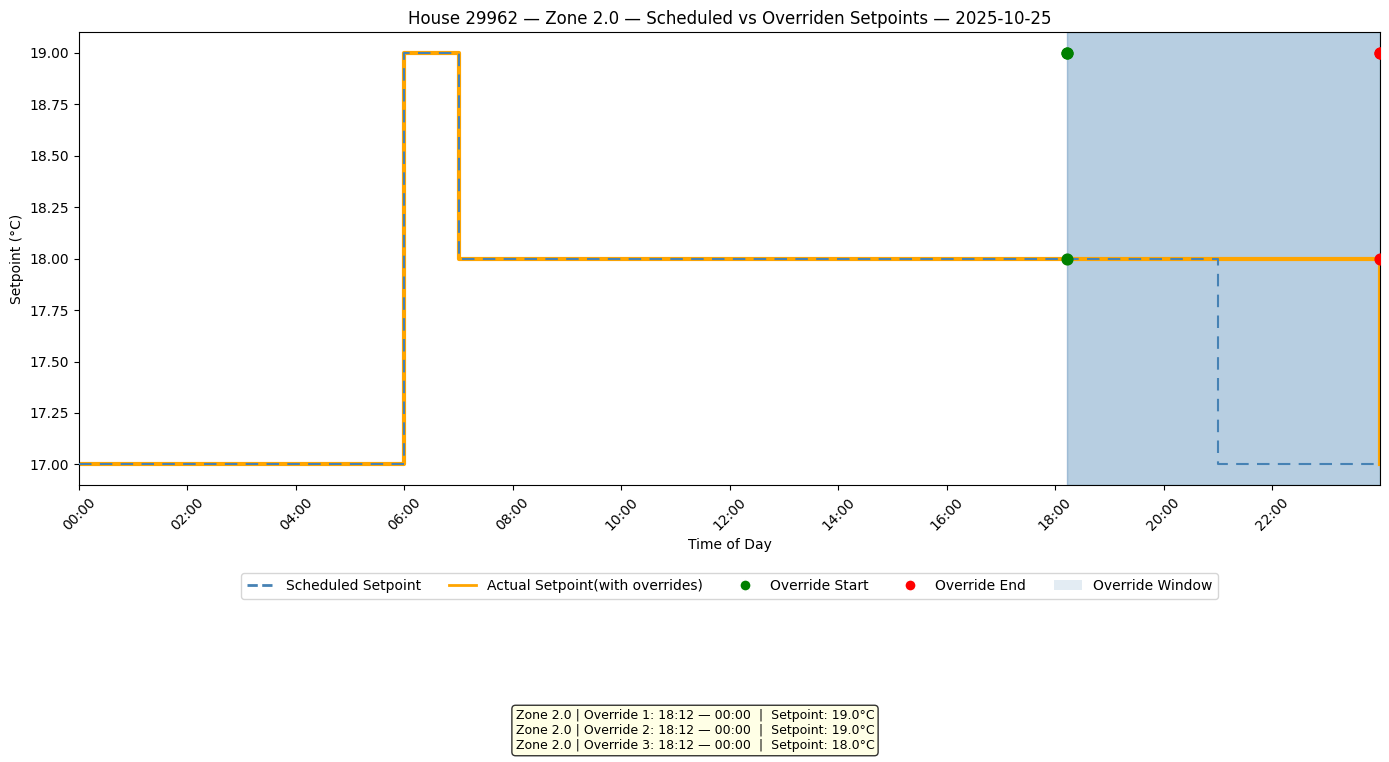

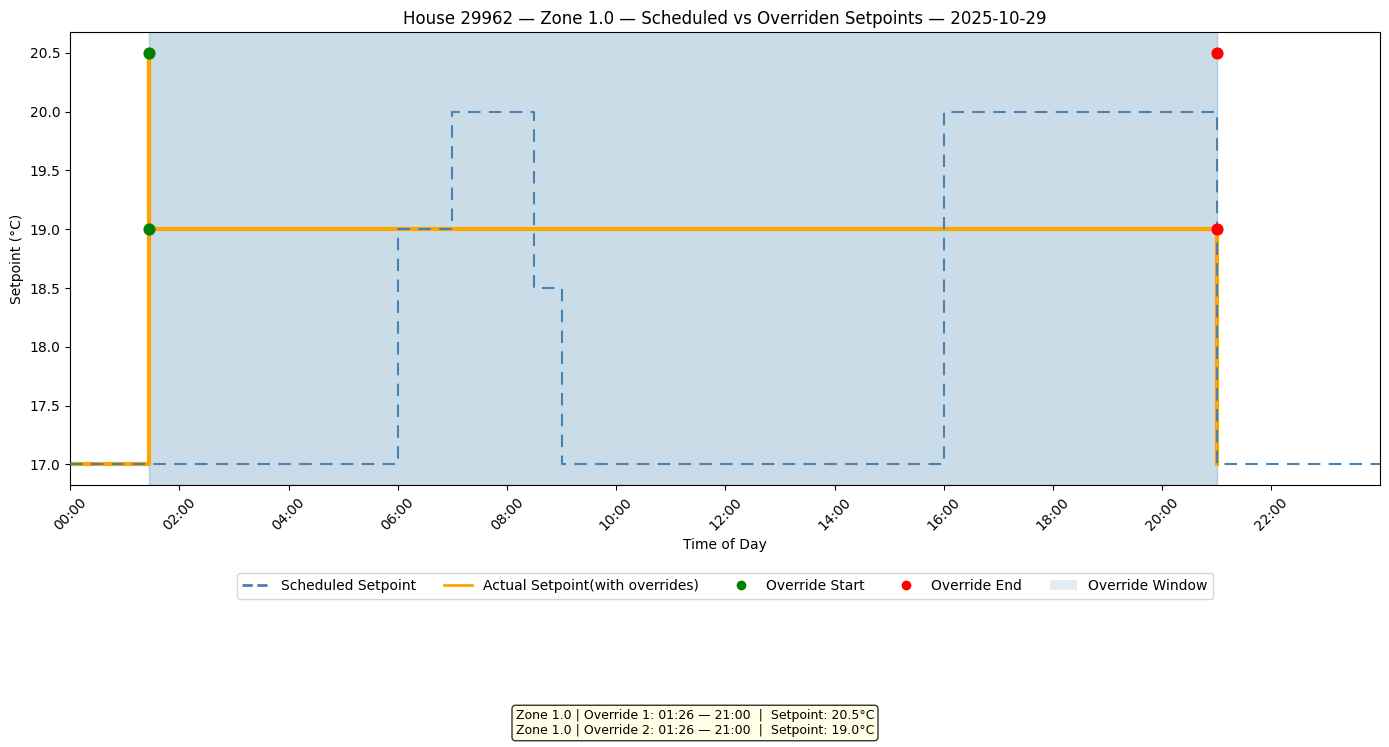

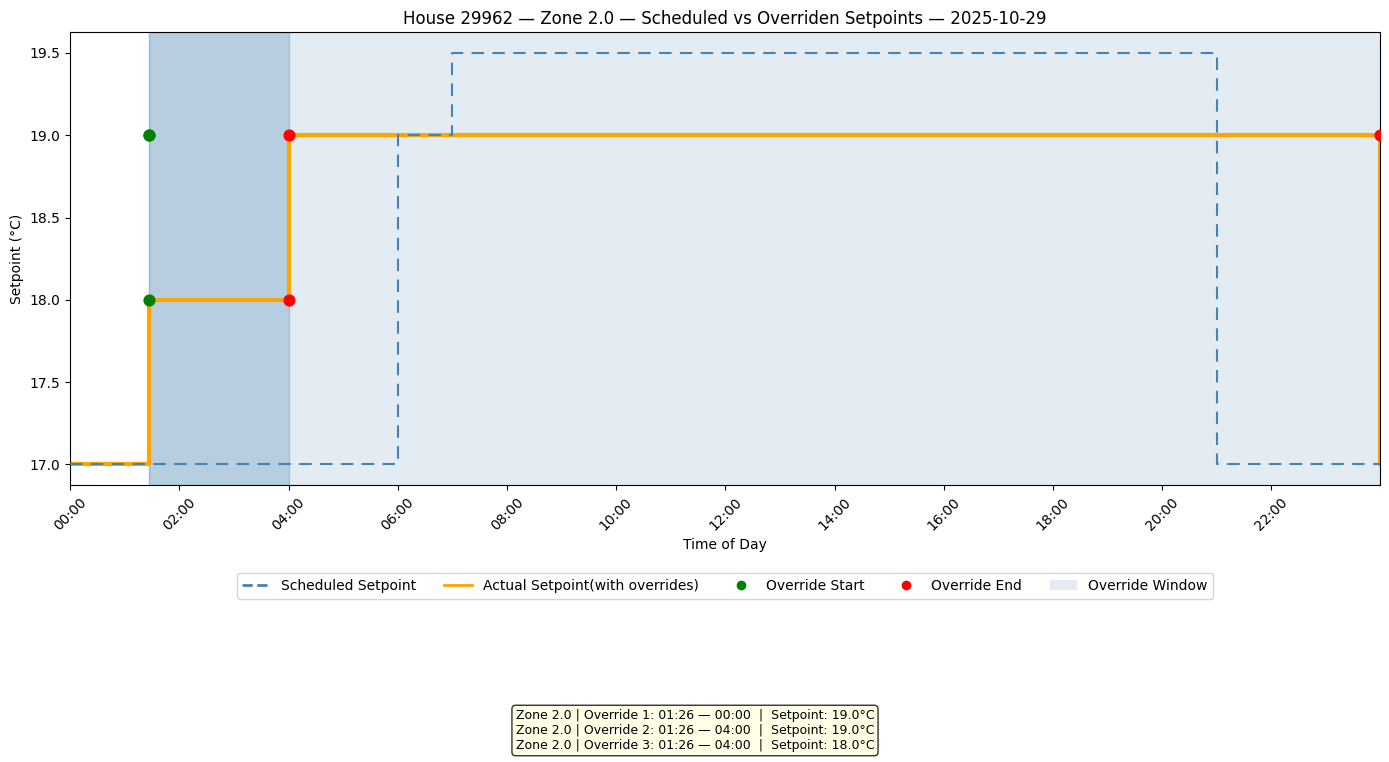

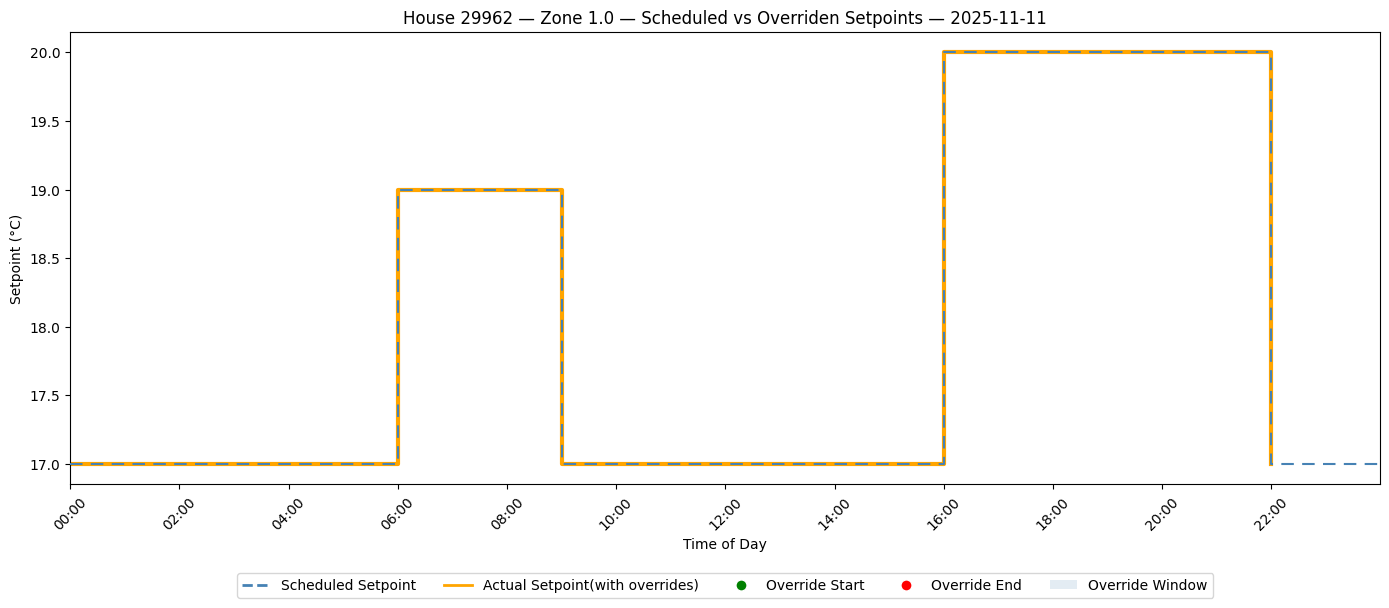

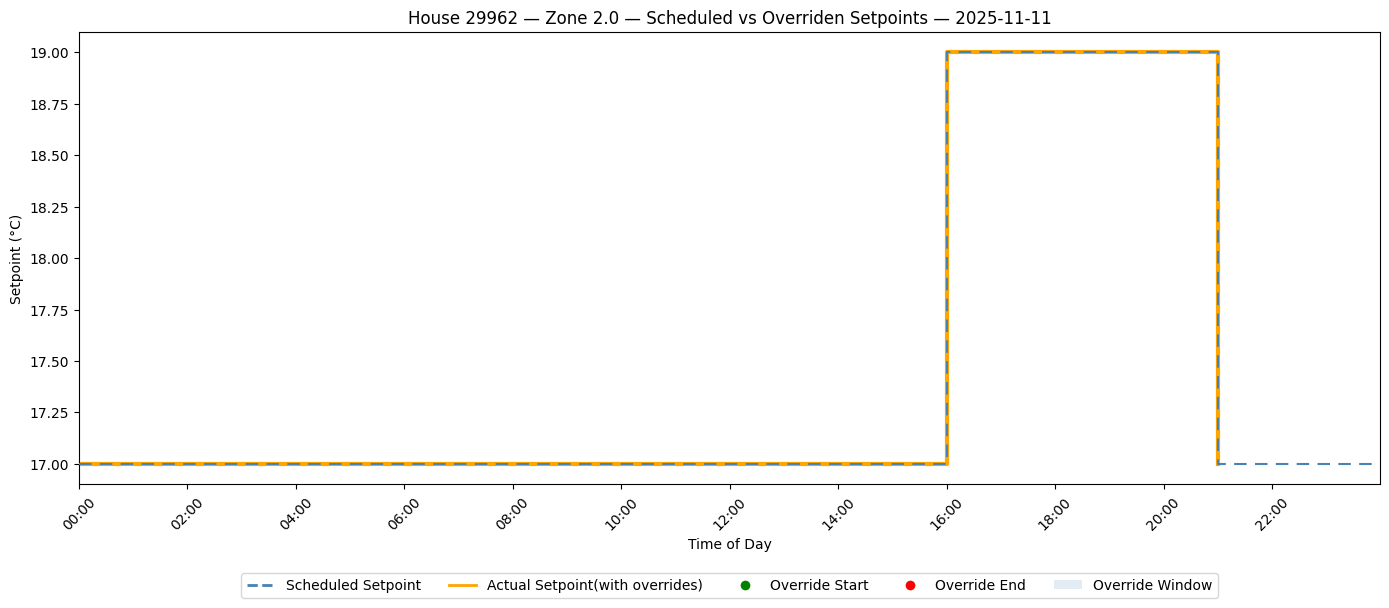

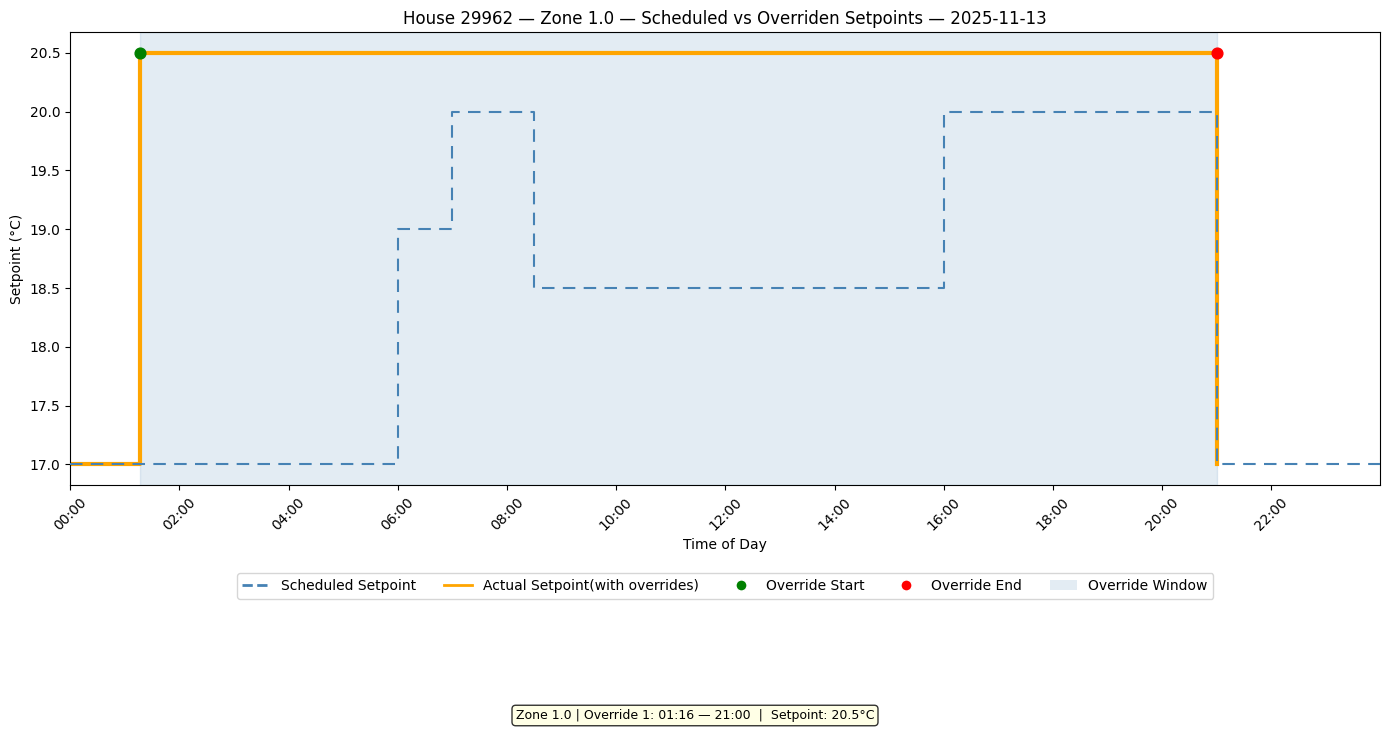

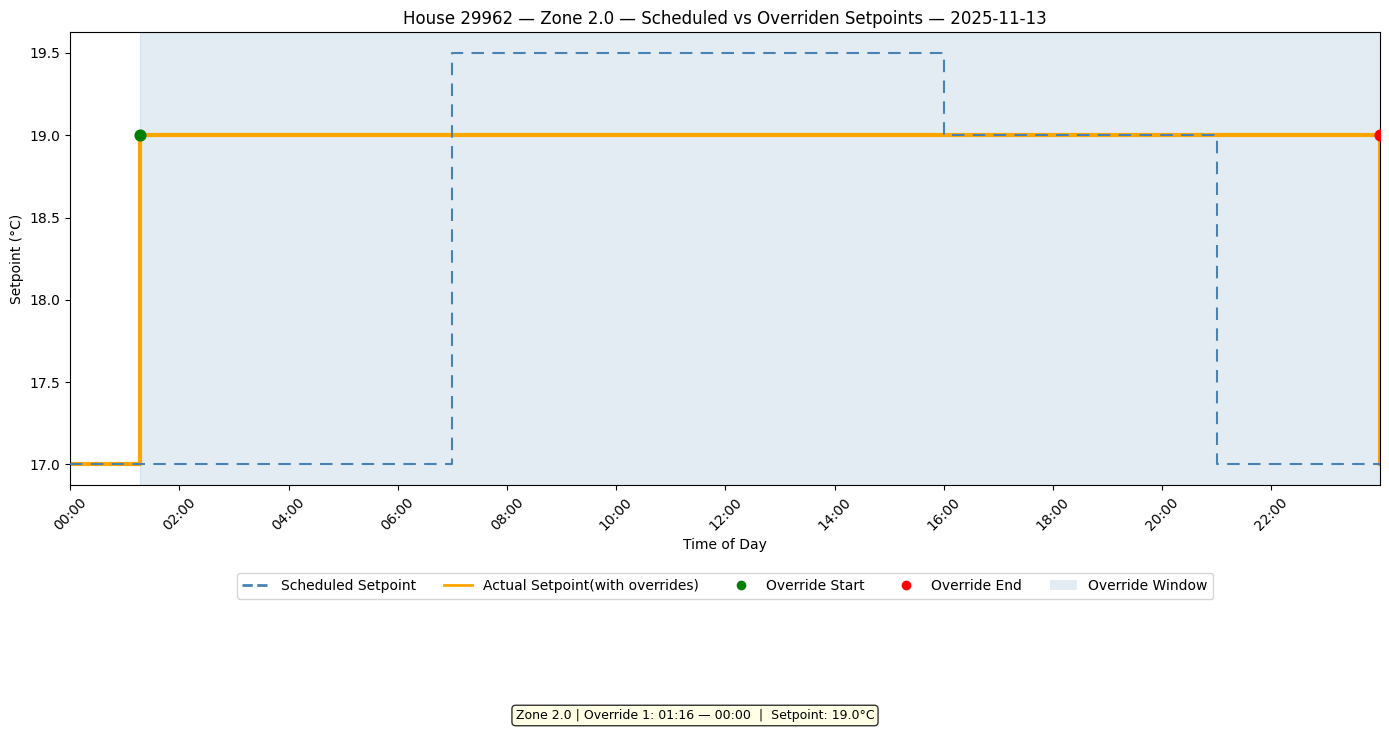

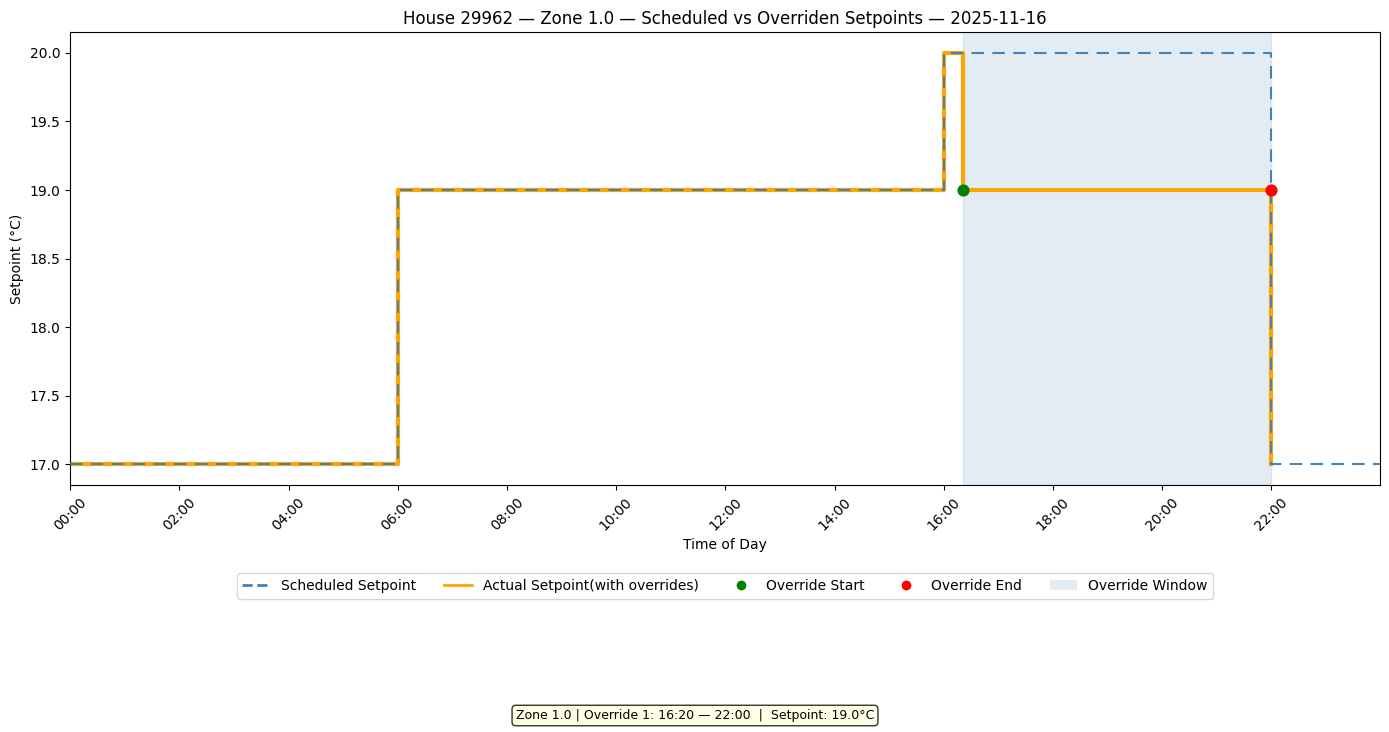

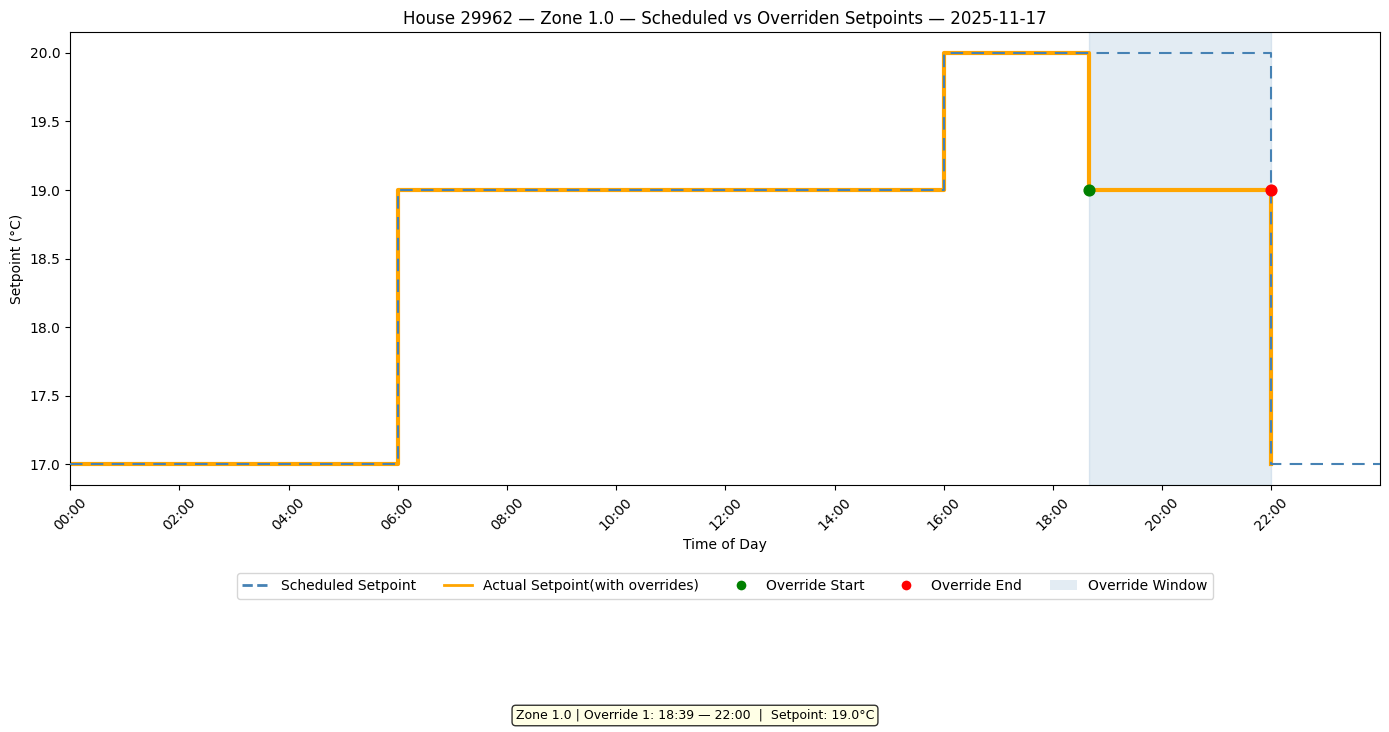

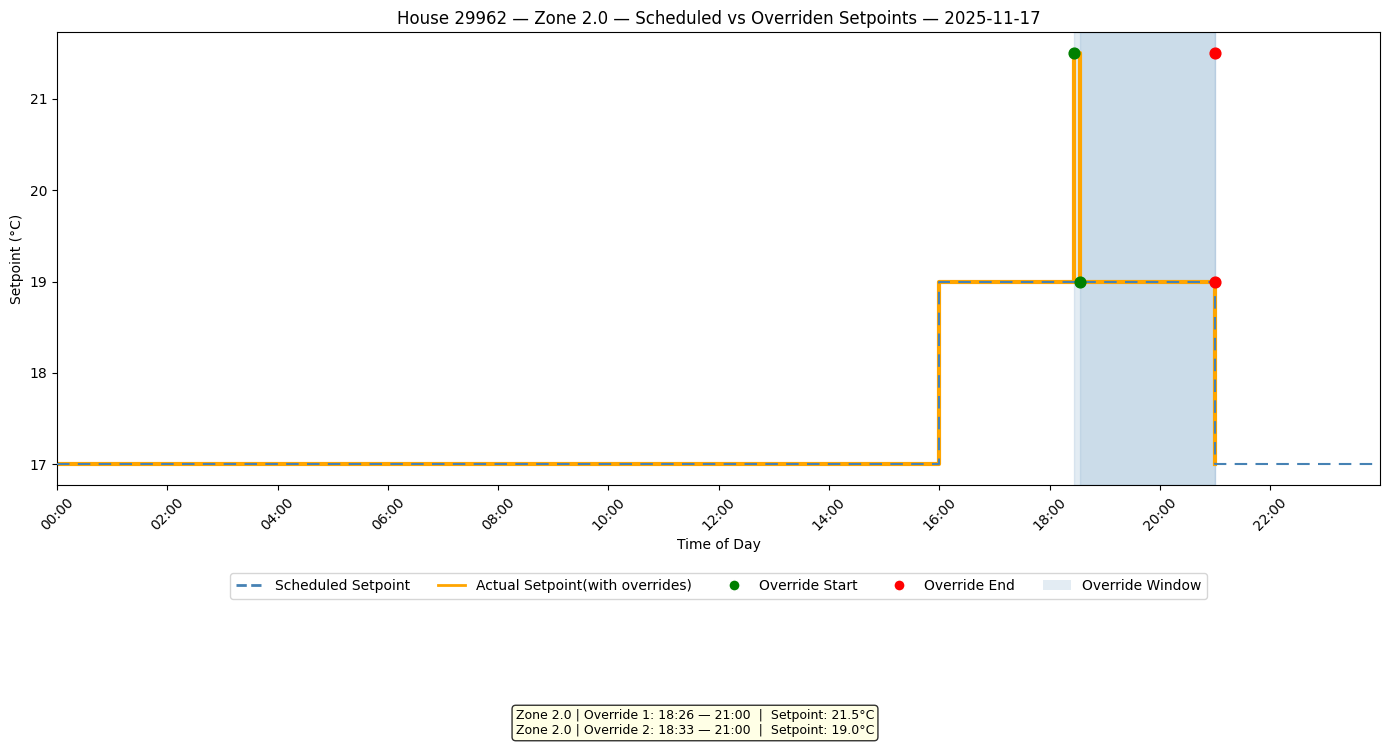

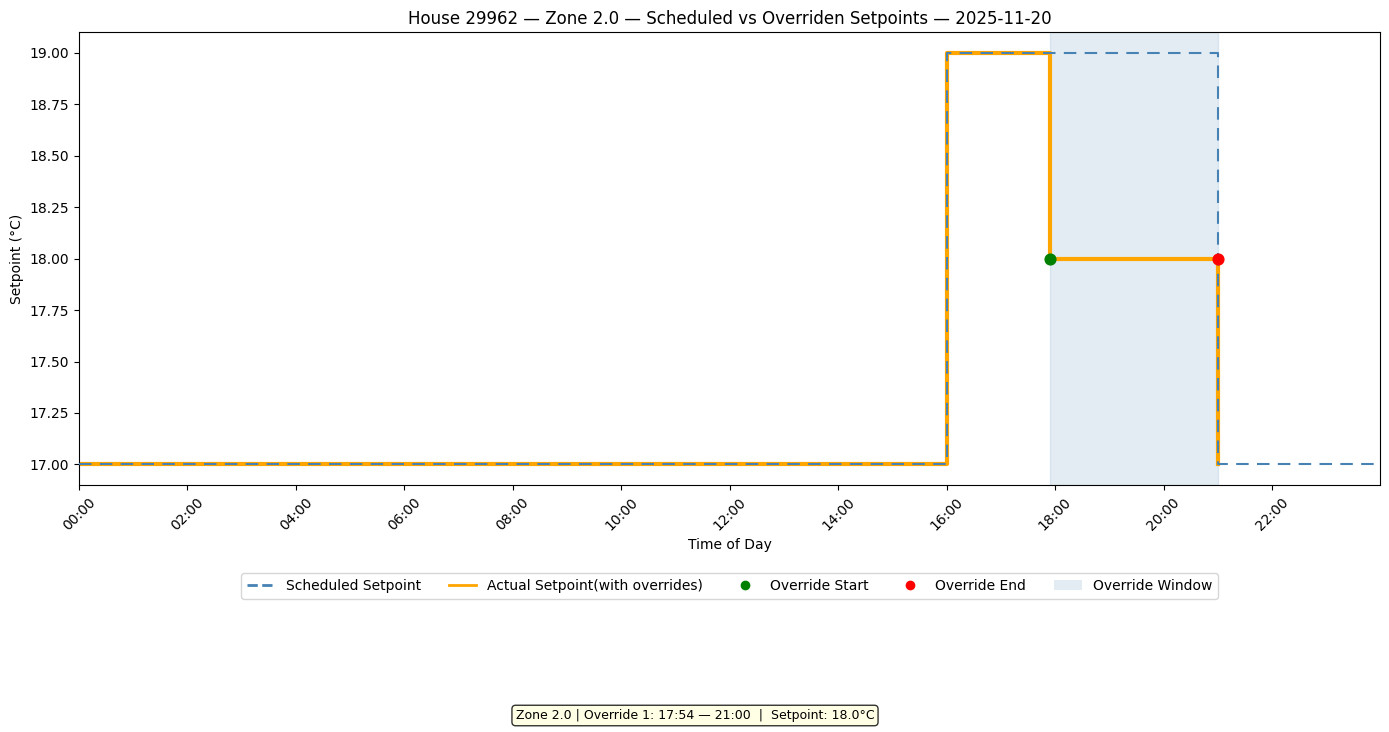

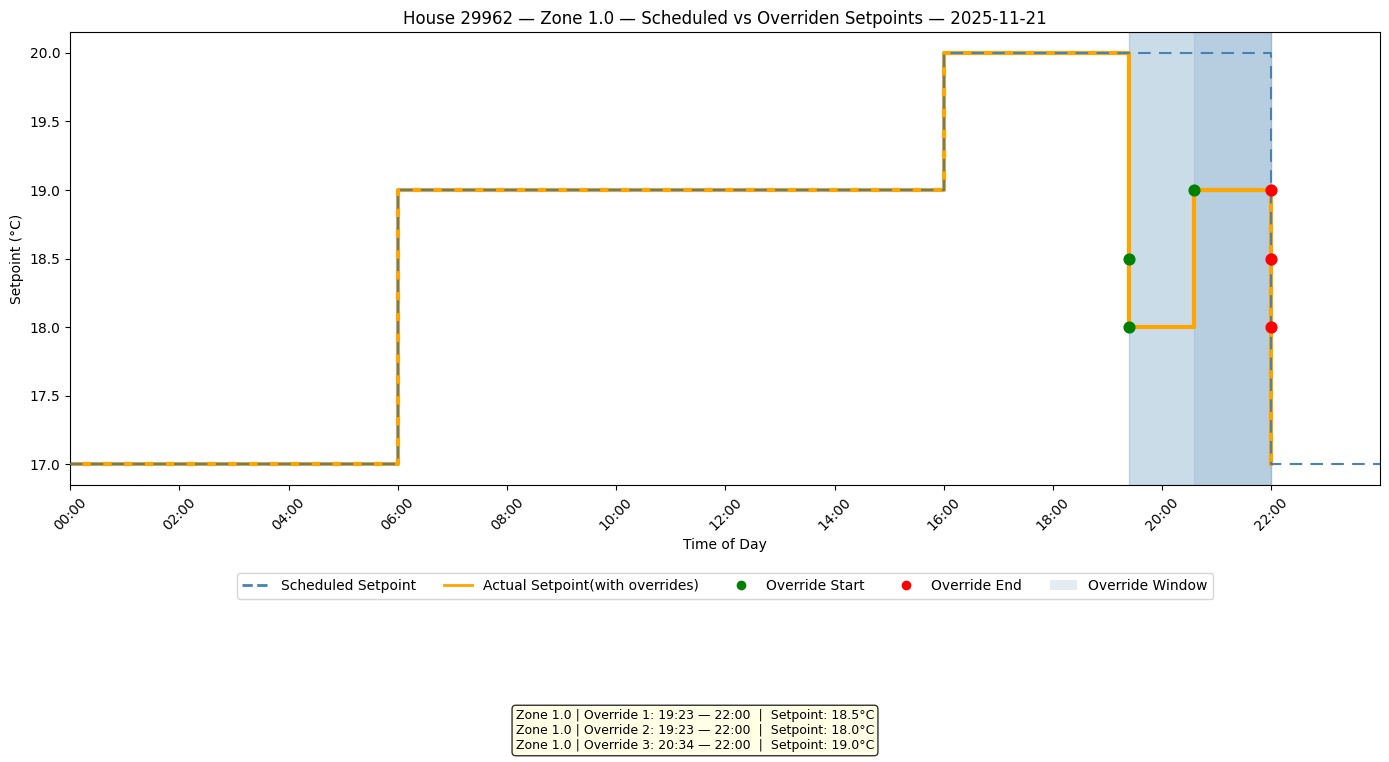

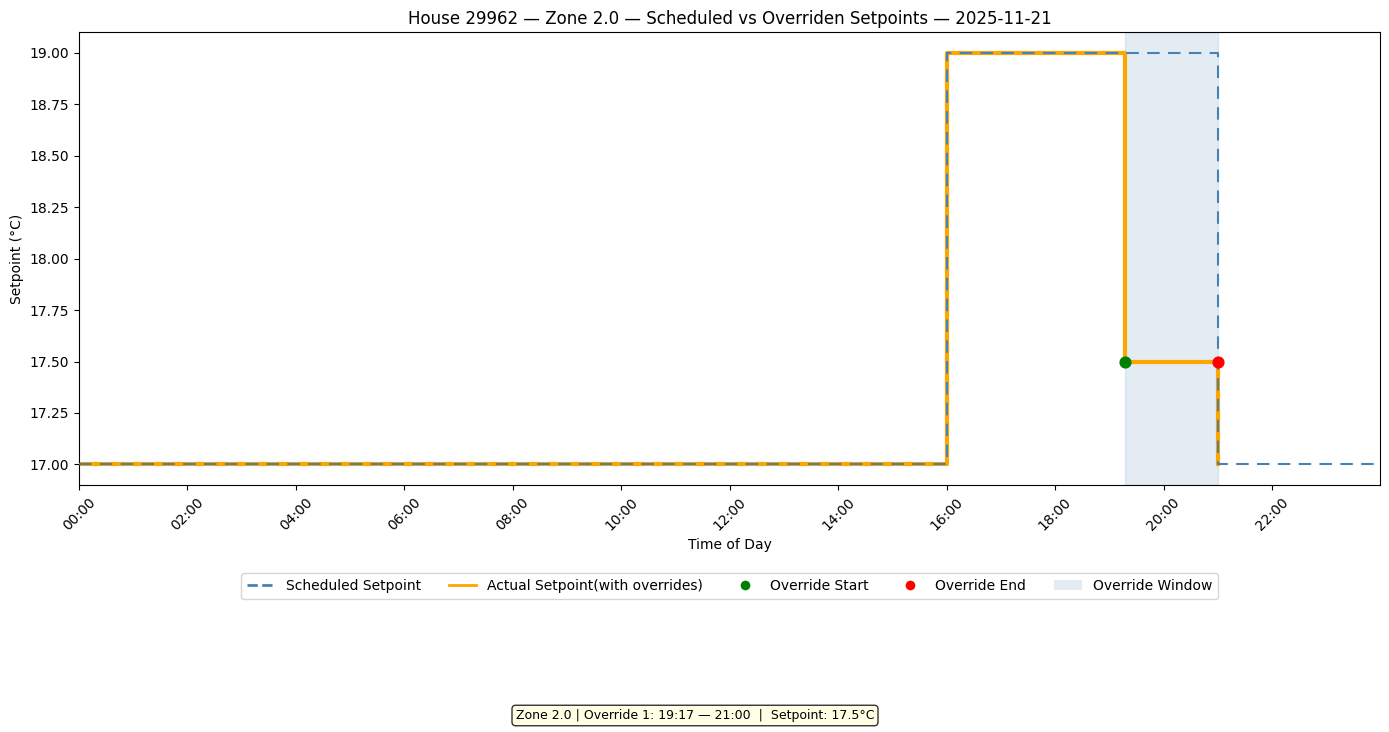

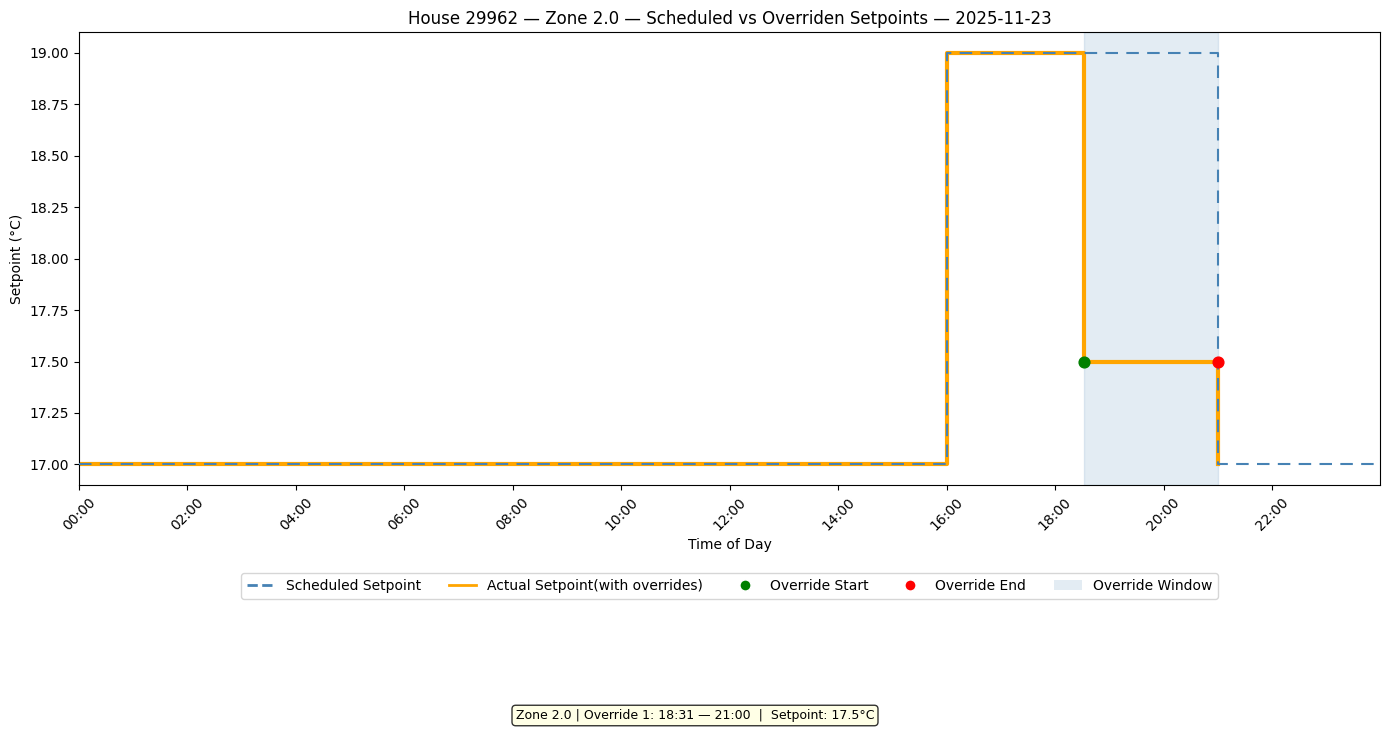

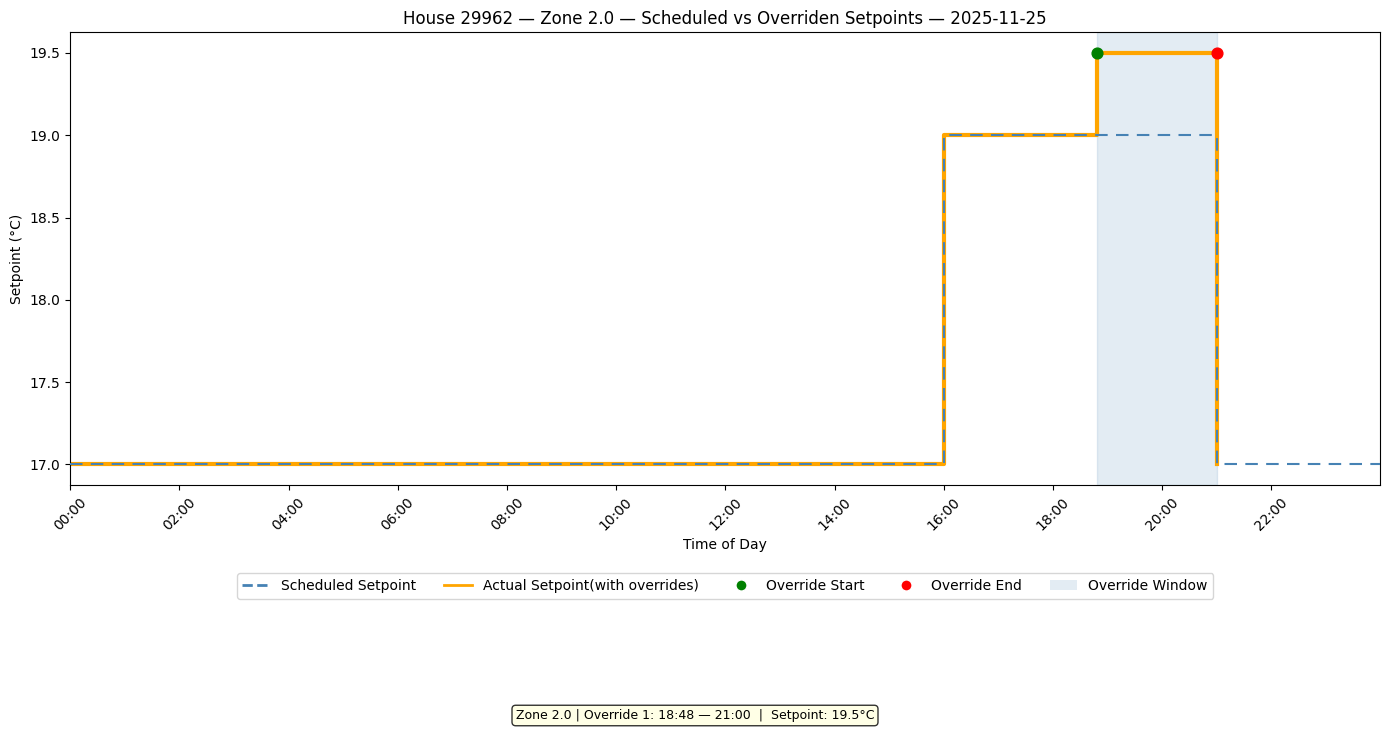

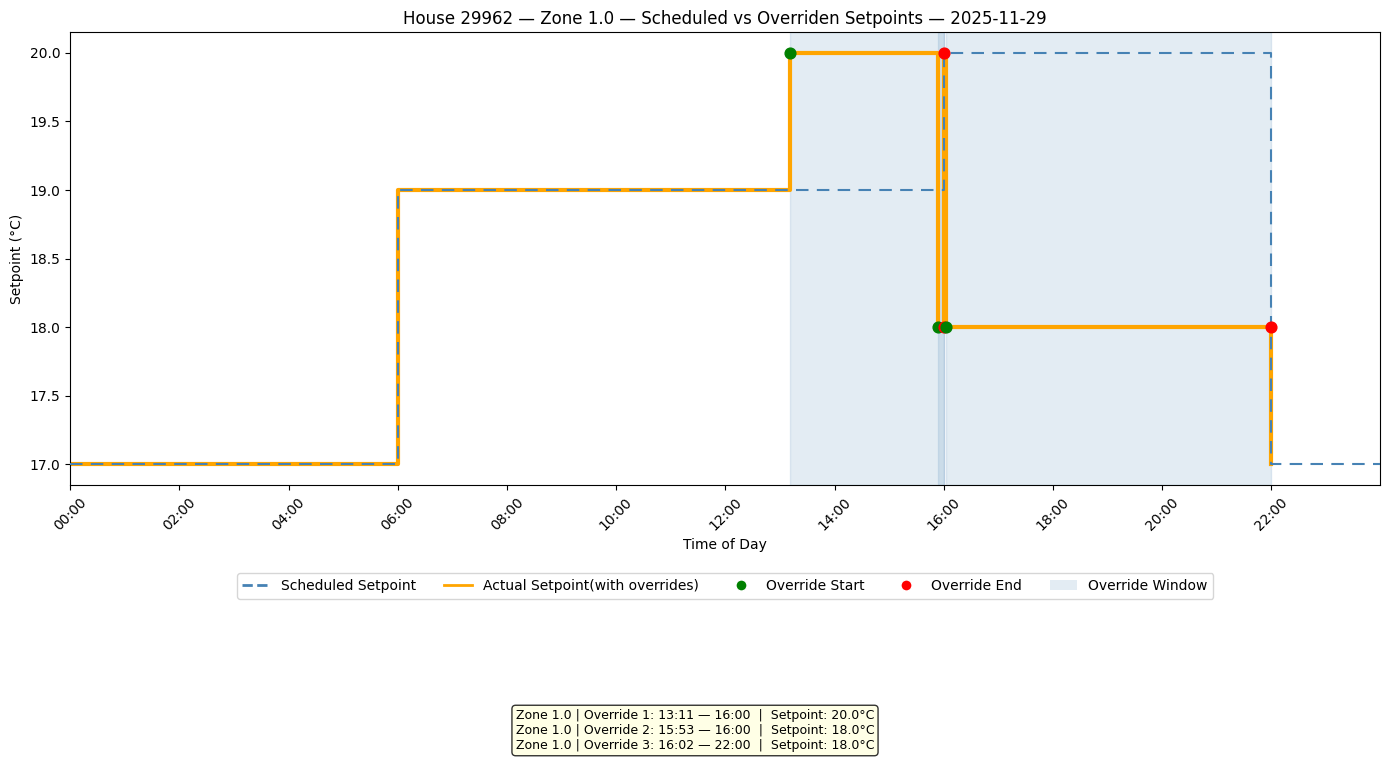

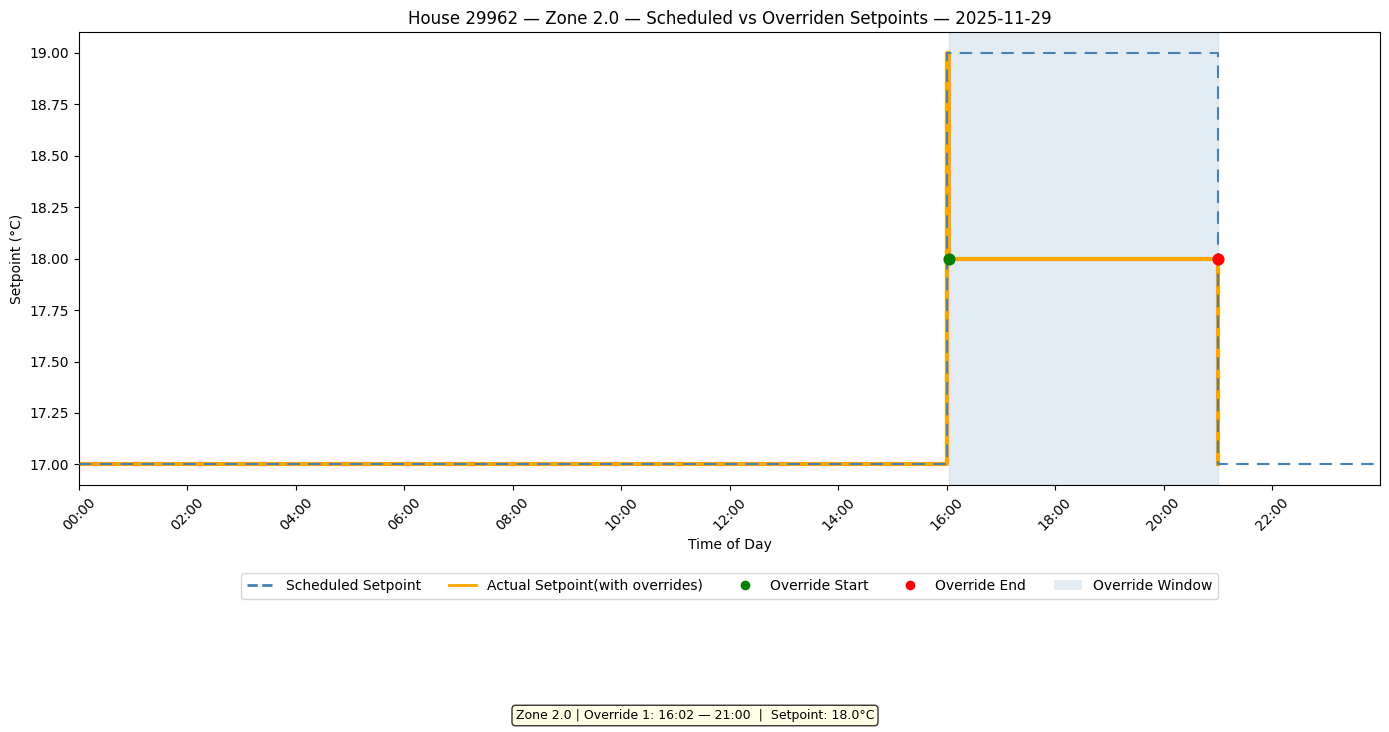

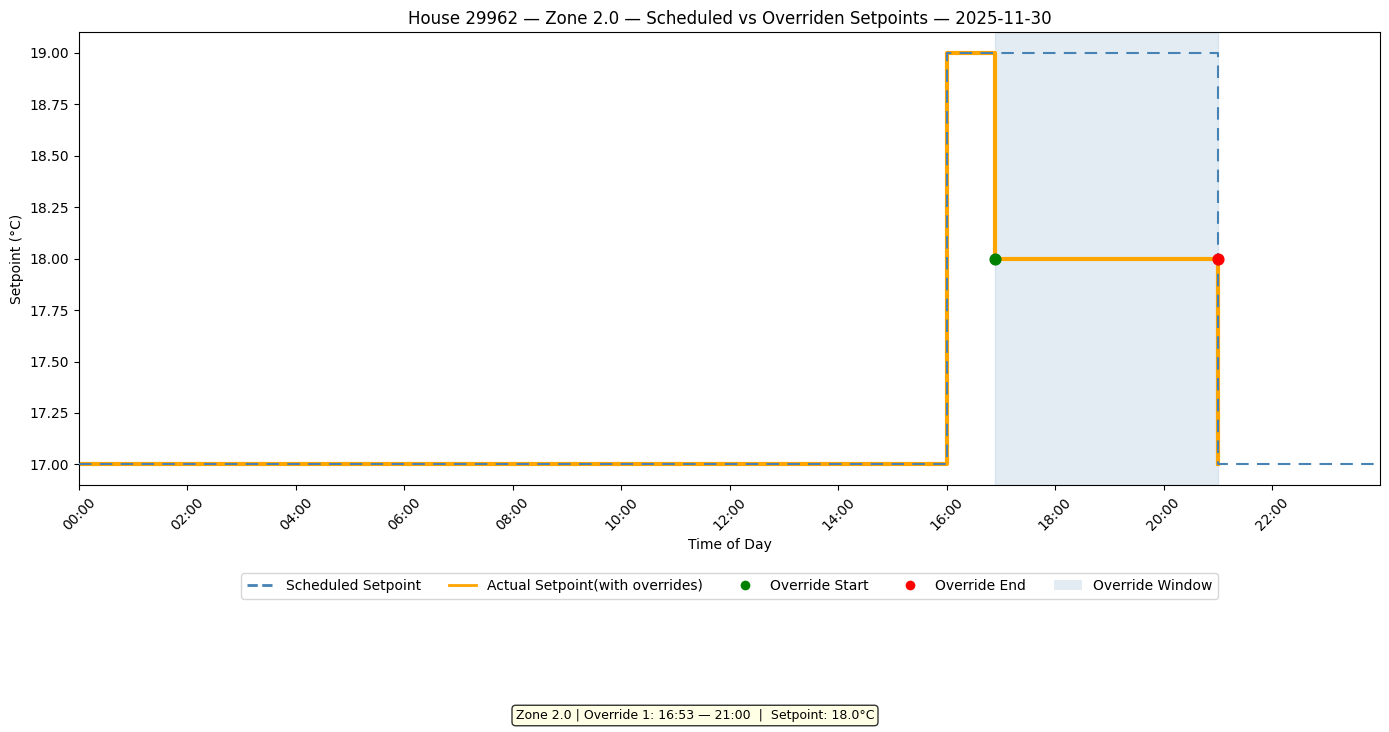

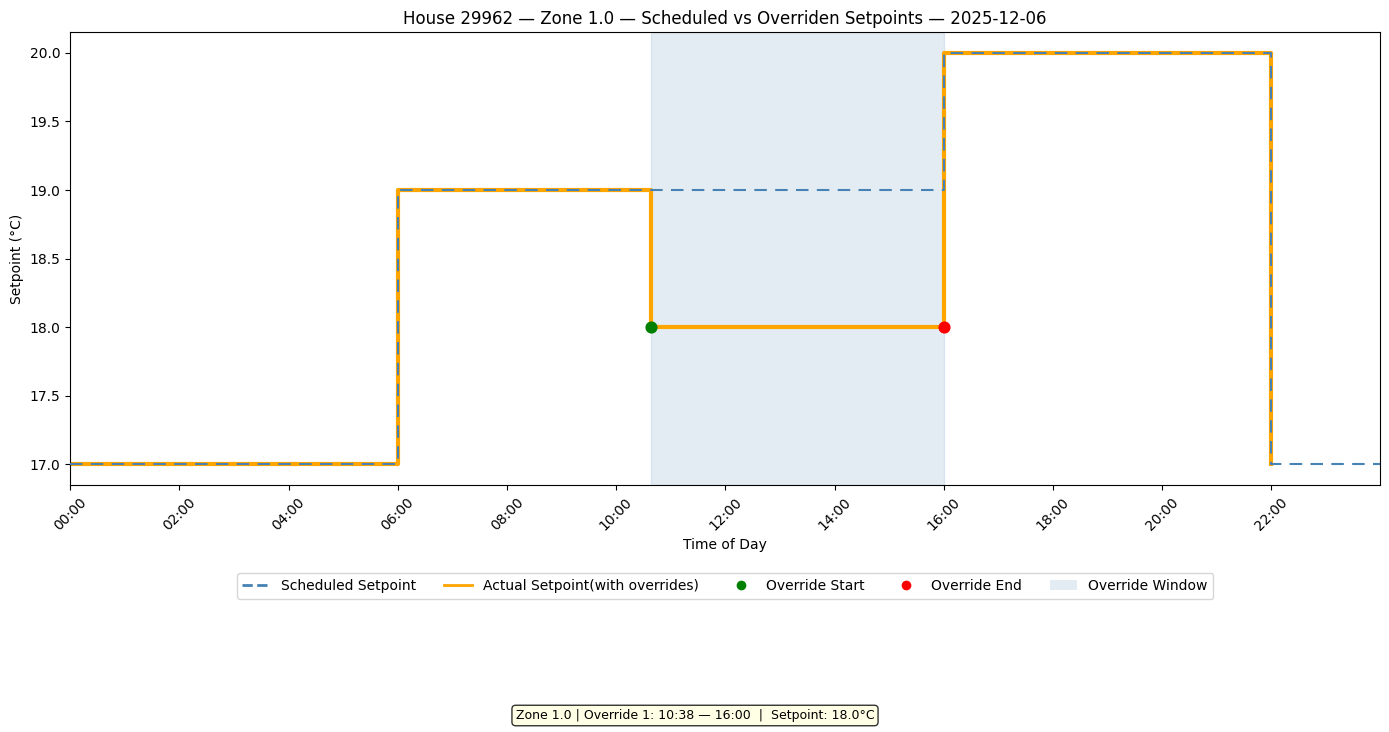

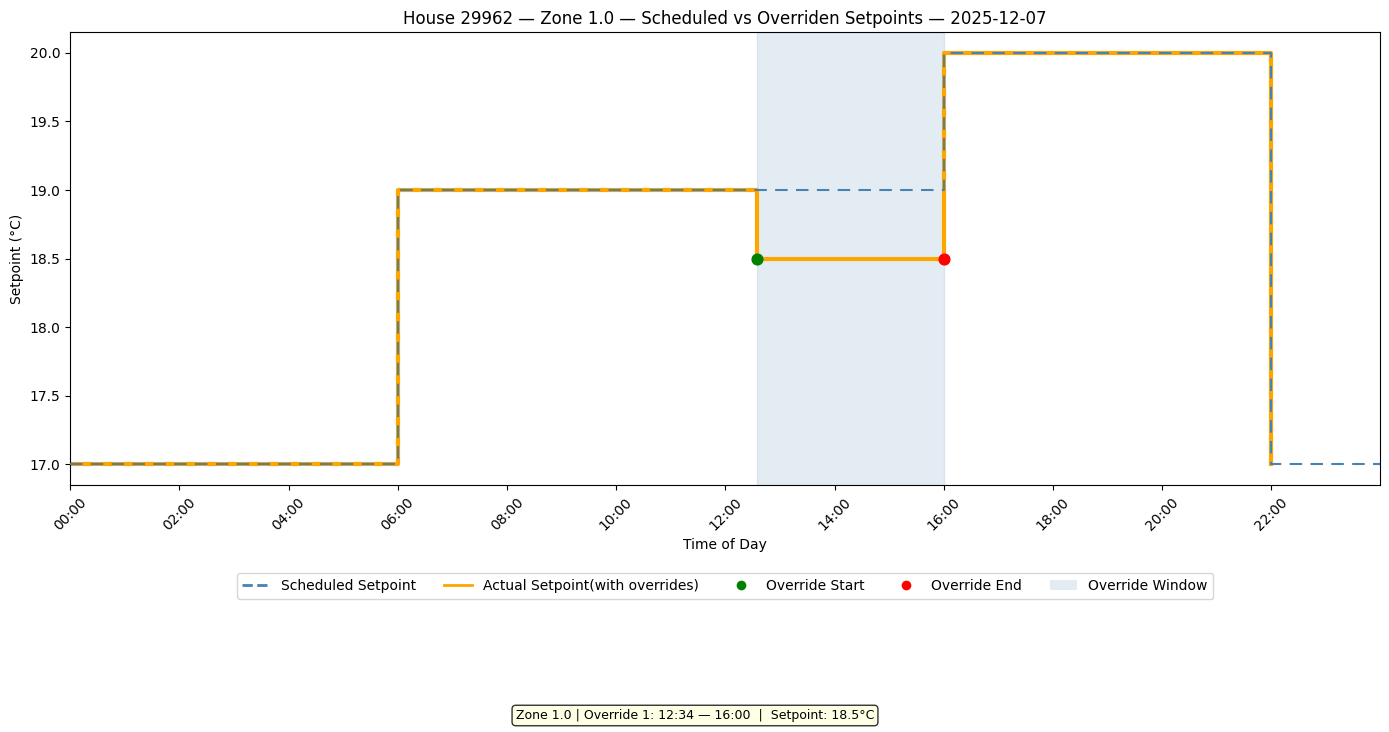

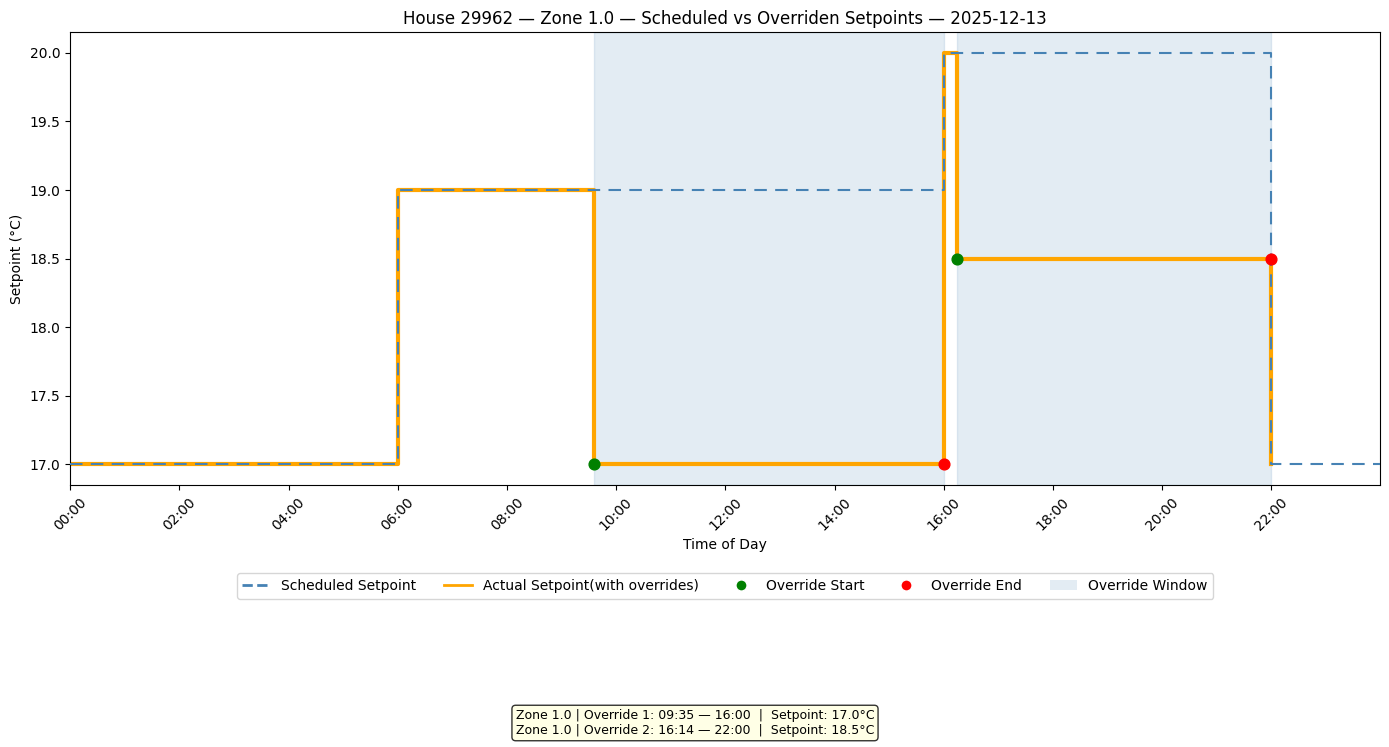

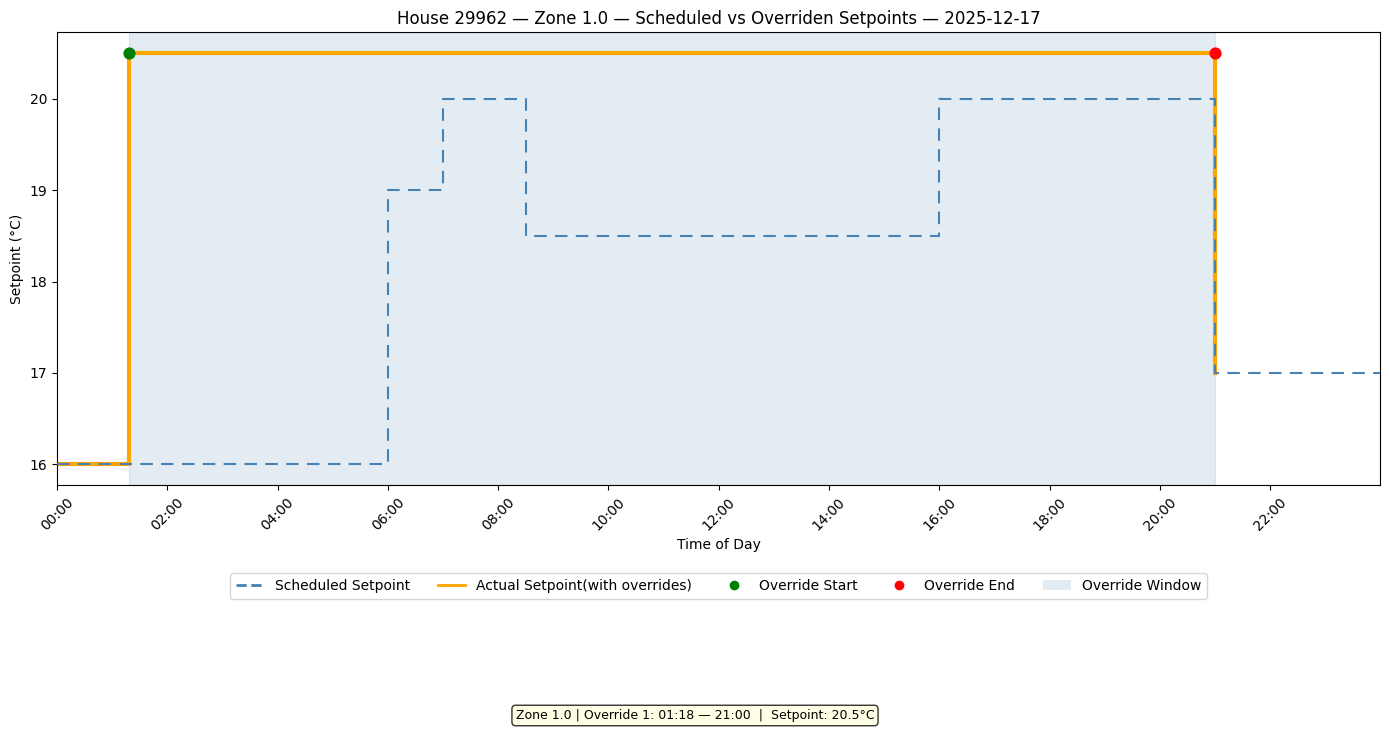

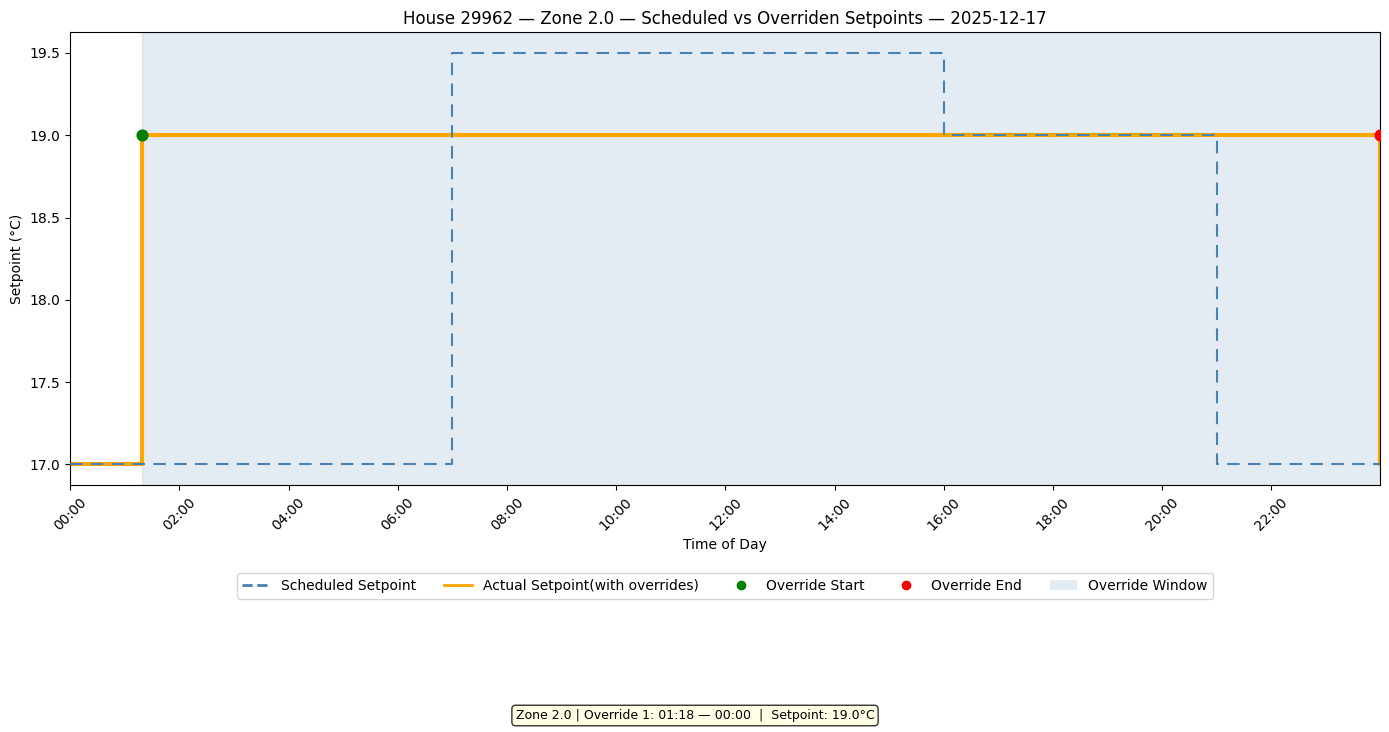

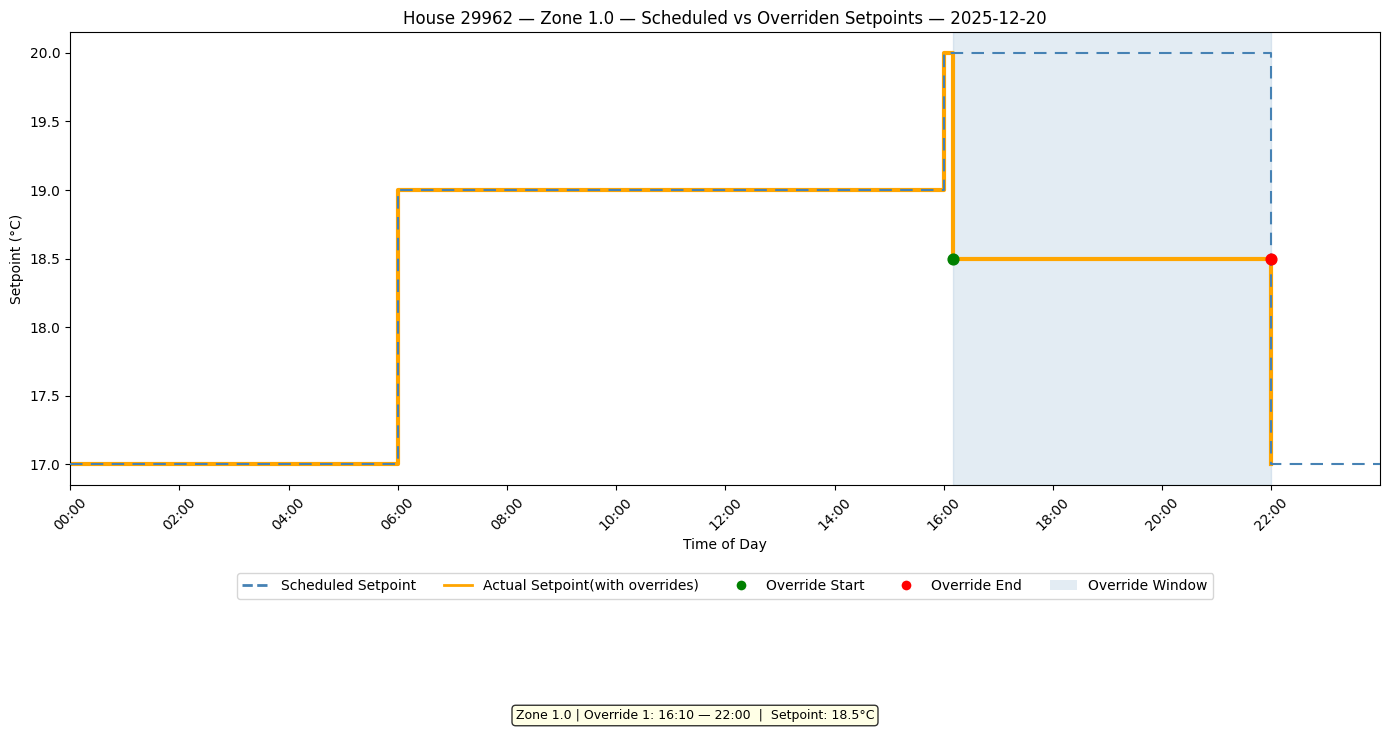

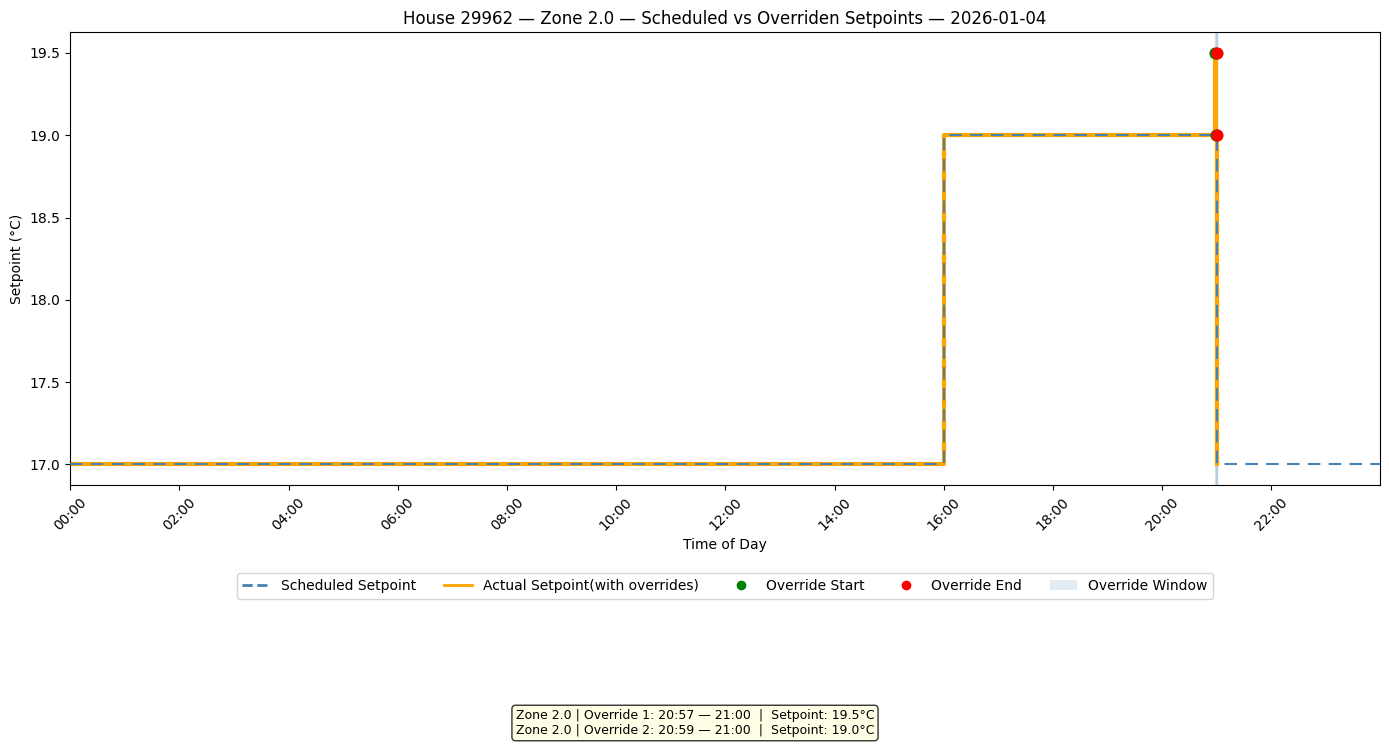

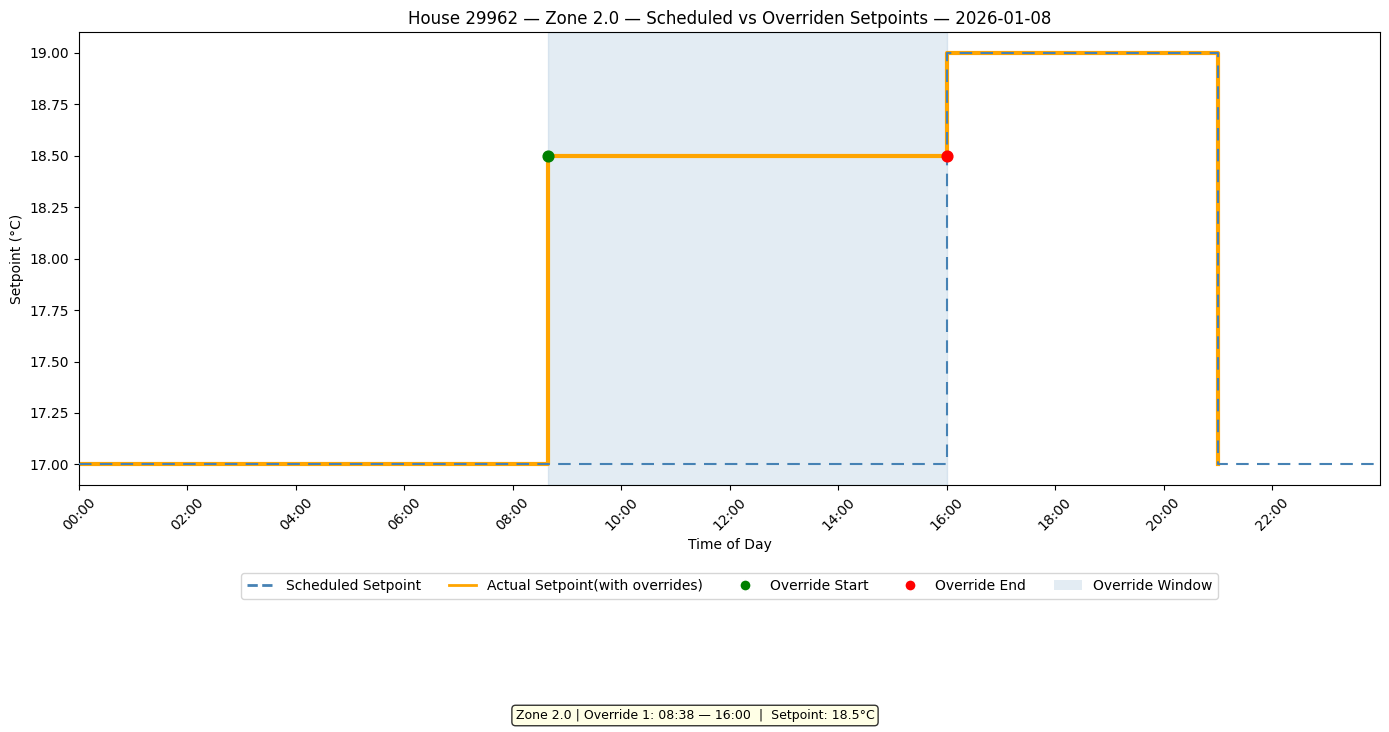

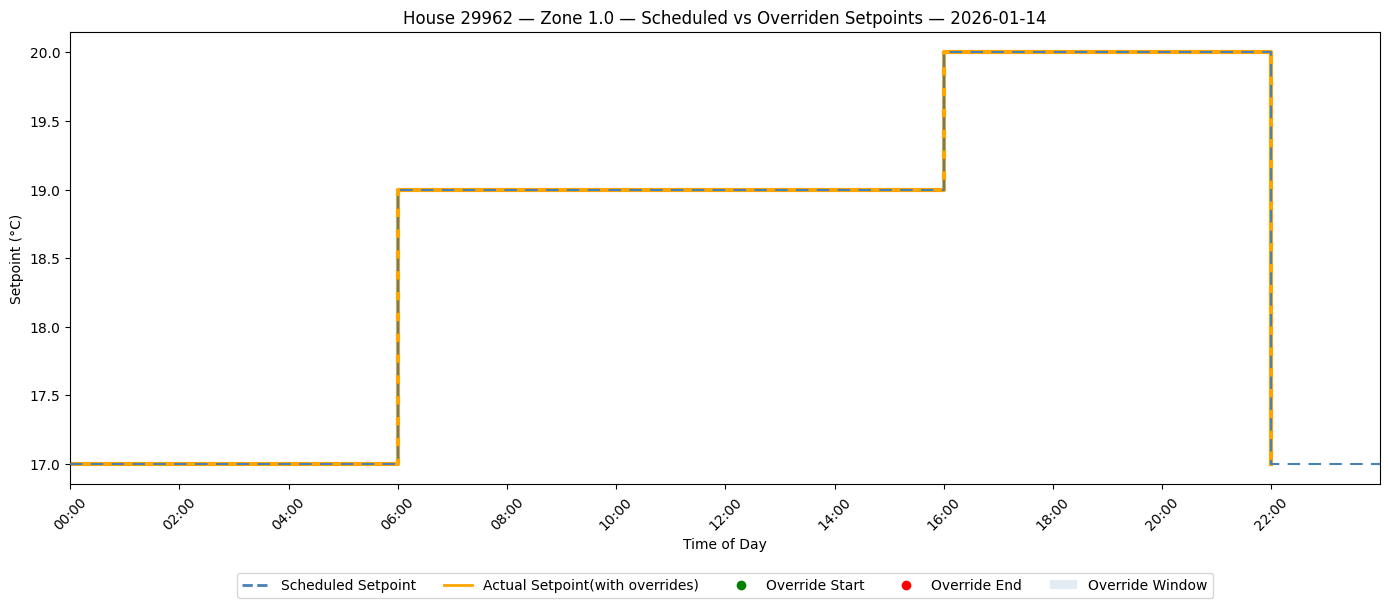

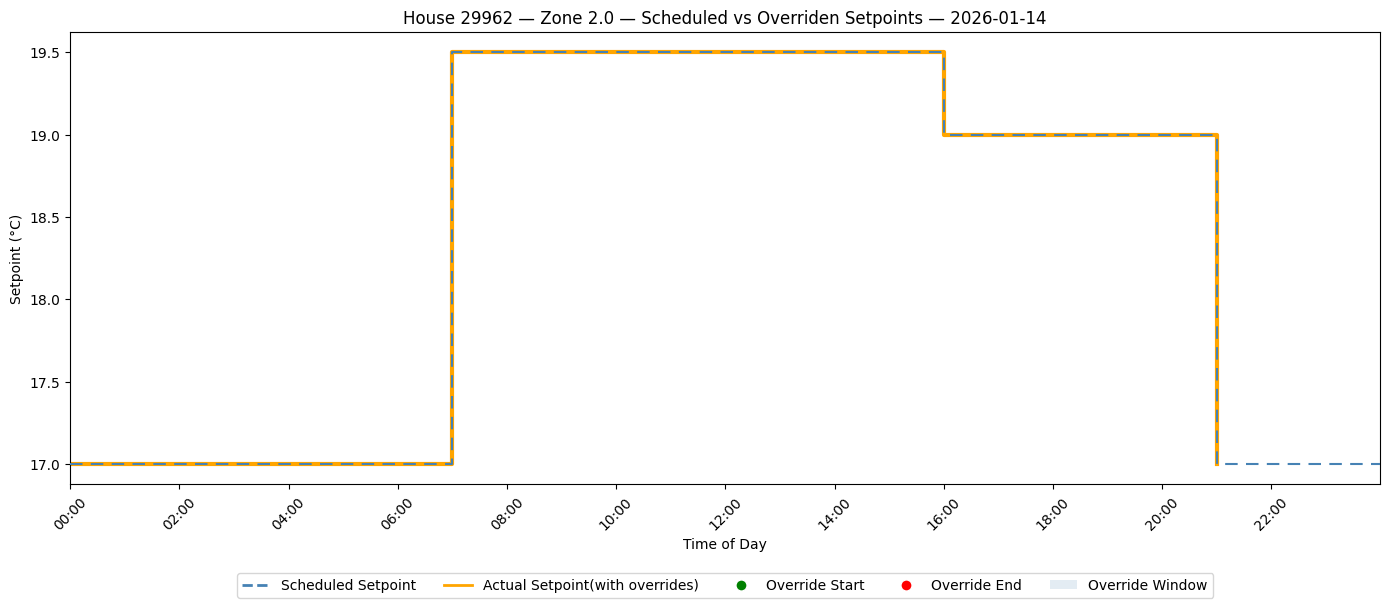

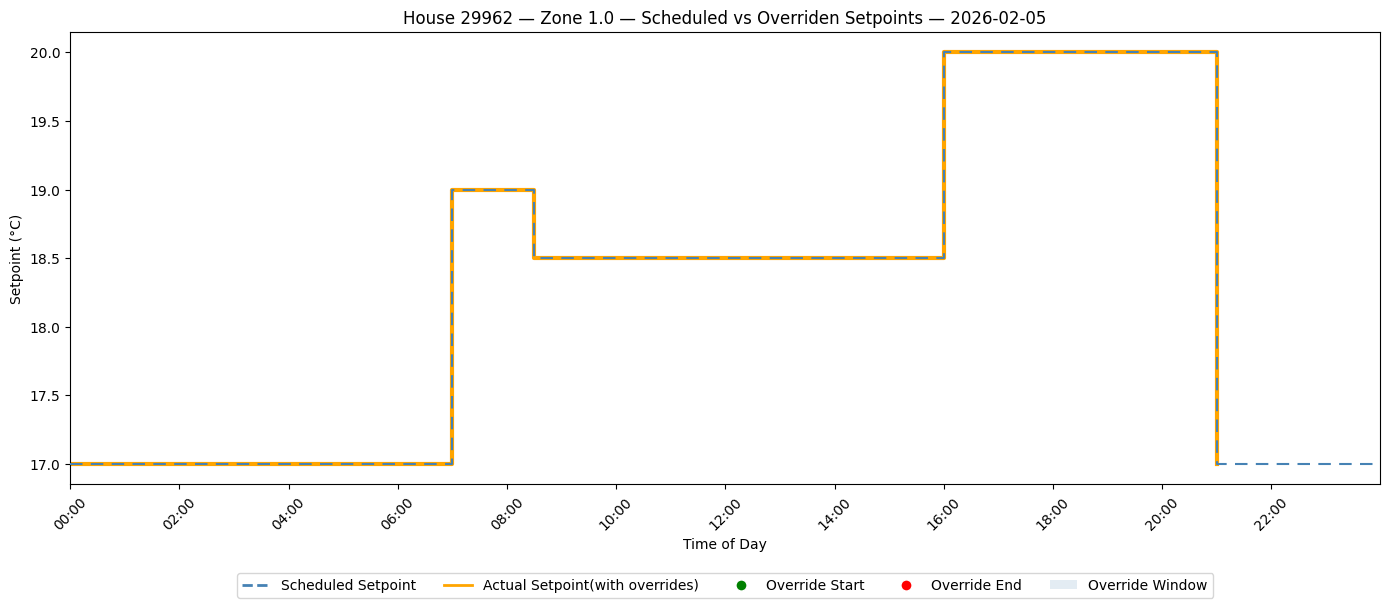

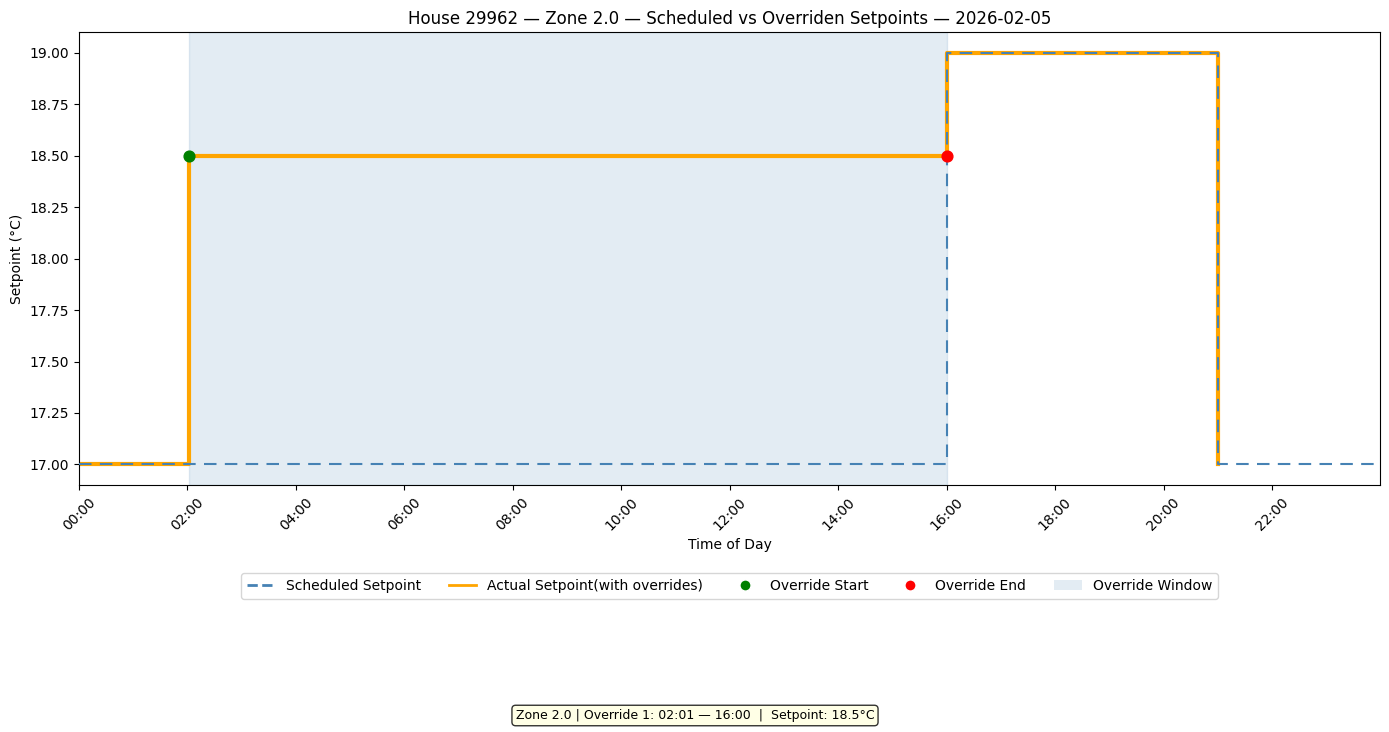

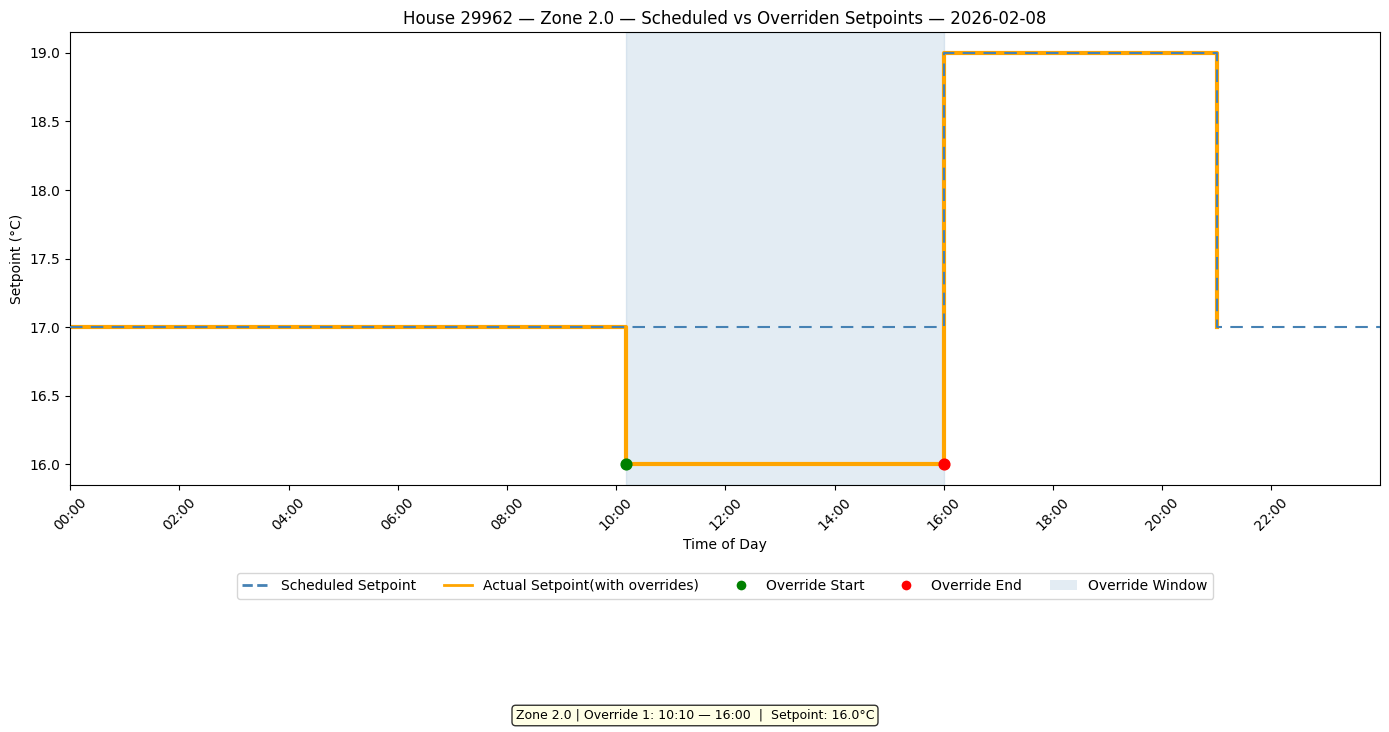

In [12]:
def safe_tz_convert(series):
    # Converts a column to datetime and ensures it is UTC timezone-aware.
    # Input: pandas Series (strings/datetimes)
    # Output: pandas Series of datetimes in UTC (invalid values become NaT)
    converted = pd.to_datetime(series, errors="coerce")
    if converted.dt.tz is None:
        return converted.dt.tz_localize("UTC")
    else:
        return converted.dt.tz_convert("UTC")

def to_hour(series):
    # Converts datetime values into a decimal hour of the day.
    # Example: 13:30 -> 13.5
    # Input: datetime Series
    # Output: float Series (0–24 range)
    return series.dt.hour + series.dt.minute / 60 + series.dt.second / 3600

def time_str_to_hour(time_series):
    # Converts "HH:MM" strings into a decimal hour.
    # Example: "06:30" -> 6.5
    # Input: string Series like "HH:MM"
    # Output: float Series (NaN if parsing fails)
    dt = pd.to_datetime(time_series, format="%H:%M", errors="coerce")
    return dt.dt.hour + dt.dt.minute / 60

# Make sure Timestamp is timezone-aware UTC once, before looping
new_data["Timestamp"] = pd.to_datetime(new_data["Timestamp"], errors="coerce")
if new_data["Timestamp"].dt.tz is None:
    new_data["Timestamp"] = new_data["Timestamp"].dt.tz_localize("UTC")
else:
    new_data["Timestamp"] = new_data["Timestamp"].dt.tz_convert("UTC")

unique_dates = new_data["Timestamp"].dt.normalize().dt.date.unique()

for date in sorted(unique_dates):
    target_date = str(date)

    # Filter day (UTC date)
    day_data = new_data[new_data["Timestamp"].dt.normalize() == pd.Timestamp(target_date, tz="UTC")].copy()

    # Parse override_end to UTC
    day_data["override_end"] = safe_tz_convert(day_data["override_end"])

    # Loop per zone so the plot clearly shows which zone is overridden 
    zones = sorted(day_data["zone"].dropna().unique())

    for zone_val in zones:
        zone_data = day_data[day_data["zone"] == zone_val].copy()

        # Get a house_id for the title
        house_id_val = zone_data["house_id"].dropna().iloc[0]

        # Schedule rows: use "time" + "C"
        schedule_data = zone_data[zone_data["time"].notna() & zone_data["C"].notna()].copy()
        # Override rows: use Timestamp start + override_end + C
        override_rows = zone_data[zone_data["override_end"].notna() & zone_data["C"].notna()].copy()

        if schedule_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, 7))

        # Build schedule step function
        schedule_data["t_hour"] = time_str_to_hour(schedule_data["time"])

        # sort and keep only one row per time
        schedule_data = (
            schedule_data.sort_values("t_hour")
                         .drop_duplicates("t_hour", keep="last")
        )

        sched_hours = schedule_data["t_hour"].tolist()
        sched_temps = schedule_data["C"].tolist()

        # Add end-of-day point (carry last setpoint forward)
        sched_hours.append(23.99)
        sched_temps.append(sched_temps[-1])

        # Handles overlapping overrides
        override_lines = []

        # Ensure overrides in chronological order (for "most recent wins")
        override_rows = override_rows.sort_values("Timestamp").copy()

        if not override_rows.empty:
            override_rows["start_hour"] = to_hour(override_rows["Timestamp"])
            override_rows["end_hour"] = to_hour(override_rows["override_end"])
            override_rows.loc[override_rows["end_hour"] < override_rows["start_hour"], "end_hour"] = 23.99
        else:
            override_rows["start_hour"] = []
            override_rows["end_hour"] = []

        # Breakpoints: schedule changes + override starts/ends + end-of-day
        breakpoints = set(sched_hours)
        if not override_rows.empty:
            breakpoints.update(override_rows["start_hour"].dropna().tolist())
            breakpoints.update(override_rows["end_hour"].dropna().tolist())
        breakpoints.add(23.99)
        breakpoints = sorted(breakpoints)

        def scheduled_at(t):
            # Returns the scheduled setpoint at time t by finding the last schedule time <= t
            idx = max(i for i, h in enumerate(sched_hours) if h <= t)
            return sched_temps[idx]

        def actual_at(t):
            # Returns the actual setpoint at time t:
            # - if an override is active at t, use override temperature (most recent wins)
            # - otherwise use the scheduled temperature
            if override_rows.empty:
                return scheduled_at(t)
            active = override_rows[(override_rows["start_hour"] <= t) & (t < override_rows["end_hour"])]
            if not active.empty:
                row = active.sort_values(["start_hour"]).iloc[-1]
                return row["C"]
            return scheduled_at(t)

        # Build actual series (collapse consecutive duplicates)
        actual_hours, actual_temps = [], []
        prev = None
        for t in breakpoints:
            val = actual_at(t)
            if prev is None or val != prev:
                actual_hours.append(t)
                actual_temps.append(val)
                prev = val

        # Plot actual + scheduled
        ax.step(actual_hours, actual_temps, where="post", color="orange", linewidth=3,
                label="Actual Setpoint (with overrides)")
        ax.step(sched_hours, sched_temps, where="post", color="steelblue", linewidth=1.5,
                linestyle="--", dashes=(6, 4), zorder=5, label="Scheduled Setpoint")

        # Plot override windows + markers (visual only)
        for i, (_, row) in enumerate(override_rows.iterrows(), start=1):
            start_hour = row["start_hour"]
            end_hour = row["end_hour"]
            temp = row["C"]

            ax.axvspan(start_hour, end_hour, alpha=0.15, color="steelblue")
            ax.scatter(start_hour, temp, color="green", zorder=6, s=60)
            ax.scatter(end_hour, temp, color="red", zorder=6, s=60)

            start_fmt = f"{int(start_hour):02d}:{int((start_hour % 1) * 60):02d}"
            end_fmt = f"{int(end_hour):02d}:{int((end_hour % 1) * 60):02d}" if end_hour < 23.99 else "00:00"
            override_lines.append(
                f"Zone {zone_val} | Override {i}: {start_fmt} — {end_fmt}  |  Setpoint: {temp}°C"
            )

        # Legend (below plot)
        legend_elements = [
            Line2D([0], [0], color="steelblue", linewidth=2, linestyle="--", label="Scheduled Setpoint"),
            Line2D([0], [0], color="orange", linewidth=2, label="Actual Setpoint(with overrides)"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=8, label="Override Start"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=8, label="Override End"),
            plt.Rectangle((0, 0), 1, 1, fc="steelblue", alpha=0.15, label="Override Window"),
        ]
        ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.18),
                  ncol=5, frameon=True)

        # Override summary text
        if override_lines:
            summary = "\n".join(override_lines)
            fig.text(0.5, -0.02, summary, fontsize=9, ha="center", va="top",
                     bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

        # Axis formatting
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):02d}:{int((x % 1) * 60):02d}"))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
        ax.set_xlim(0, 23.99)

        ax.set_xlabel("Time of Day")
        ax.set_ylabel("Setpoint (°C)")
        ax.set_title(f"House {house_id_val} — Zone {zone_val} — Scheduled vs Overriden Setpoints — {target_date}")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.3)
        plt.show()